# Préparation dataset FAO

Objectif : Analyser et nettoyer les 5 datasets FAO et le dataset Crop Yield pour préparer la fusion

---

## Imports et configuration

In [1]:
import pandas as pd
import sys
from pathlib import Path
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from thefuzz import process

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import time

from config.paths import DONNEES_HISTORIQUES
from config.paths import DONNEES_AGRO_CLIMATIQUES
from config.paths import DONNEES_PROCESSED
from config.config import RANDOM_STATE

## Données FAO
Source : yield.csv

### Chargement et vue d'ensemble

In [2]:
df_rendements_fao = pd.read_csv(DONNEES_AGRO_CLIMATIQUES / "yield.csv")
print(f"Shape : {df_rendements_fao.shape}")
df_rendements_fao.head()

Shape : (56717, 12)


,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260
3,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1964,1964,hg/ha,14257
4,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1965,1965,hg/ha,14400


In [3]:
df_rendements_fao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56717 entries, 0 to 56716
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Domain Code   56717 non-null  object
 1   Domain        56717 non-null  object
 2   Area Code     56717 non-null  int64 
 3   Area          56717 non-null  object
 4   Element Code  56717 non-null  int64 
 5   Element       56717 non-null  object
 6   Item Code     56717 non-null  int64 
 7   Item          56717 non-null  object
 8   Year Code     56717 non-null  int64 
 9   Year          56717 non-null  int64 
 10  Unit          56717 non-null  object
 11  Value         56717 non-null  int64 
dtypes: int64(6), object(6)
memory usage: 5.2+ MB


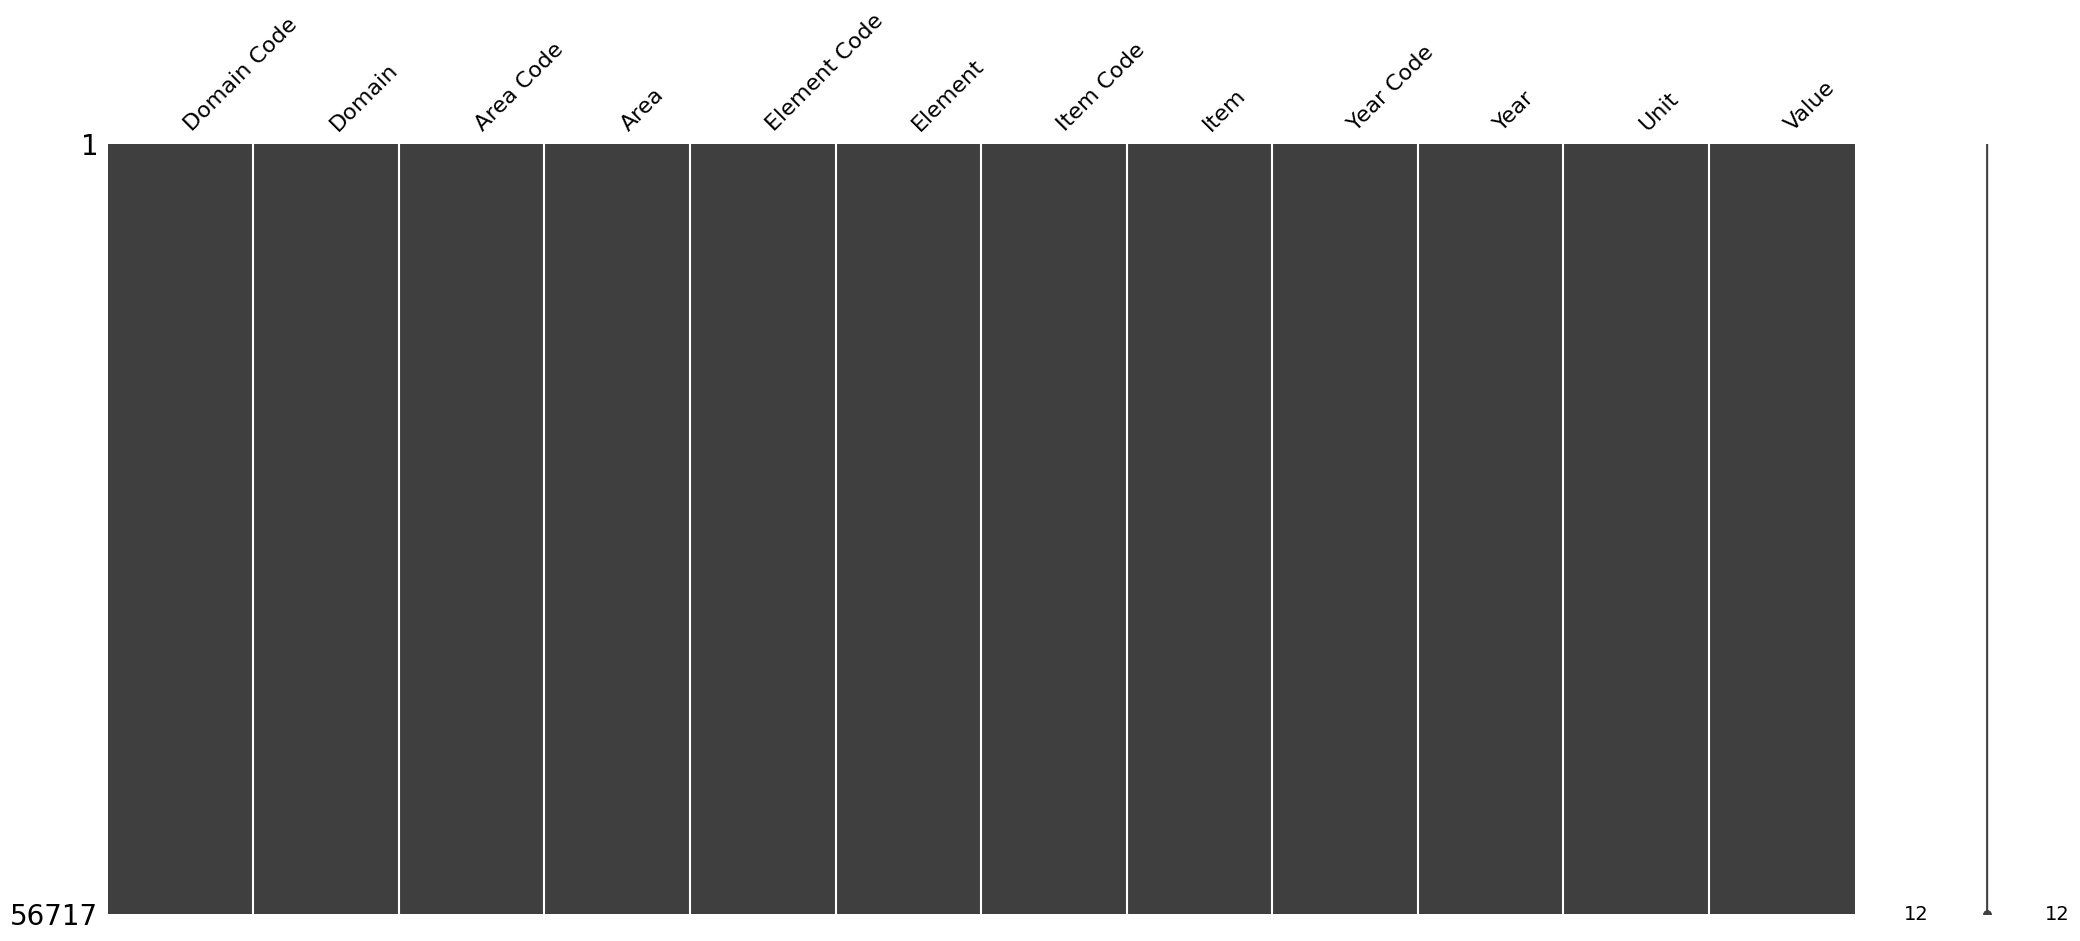

In [4]:
# Valeurs manquantes
msno.matrix(df_rendements_fao)
plt.show()

Aucune valeur manquante

### Nettoyage des colonnes

In [5]:
# Identifier les colonnes à valeur unique inutiles
print("Colonnes à valeur unique :")
for col in df_rendements_fao.columns:
    n_unique = df_rendements_fao[col].nunique()
    if n_unique == 1:
        print(f"  - {col} : {df_rendements_fao[col].unique()[0]}")

Colonnes à valeur unique :
  - Domain Code : QC
  - Domain : Crops
  - Element Code : 5419
  - Element : Yield
  - Unit : hg/ha


In [6]:
# Vérifier Year Code = Year (redondance)
print("Year Code == Year ?")
print((df_rendements_fao['Year Code'] == df_rendements_fao['Year']).all())

Year Code == Year ?
True


In [7]:
# Suppression des colonnes inutiles
colonnes_a_supprimer = ['Domain Code', 'Domain', 'Element Code', 'Element', 'Year Code', 'Unit']

print(f"Avant suppression : {df_rendements_fao.shape}")
df_rendements_fao.drop(columns=colonnes_a_supprimer, inplace=True)
print(f"Après suppression : {df_rendements_fao.shape}")

Avant suppression : (56717, 12)
Après suppression : (56717, 6)


In [8]:
# Renommer Value → yield_hg_per_ha (clarté)
df_rendements_fao.rename(columns={'Value': 'yield_hg_per_ha'}, inplace=True)
print("Colonnes après renommage :")
print(df_rendements_fao.columns.tolist())

Colonnes après renommage :
['Area Code', 'Area', 'Item Code', 'Item', 'Year', 'yield_hg_per_ha']


### Vérification des doublons

In [9]:
# Vérification
doublons = df_rendements_fao.duplicated().sum()
print(f"🕵️‍♂️ Doublons détectés : {doublons}")

if doublons > 0:
    # Suppression
    df_rendements_fao = df_rendements_fao.drop_duplicates()
    print(f"✅ Doublons supprimés. Nouvelle shape : {df_rendements_fao.shape}")
else:
    print("✅ Aucun doublon détecté.")
# -------------------------------------

🕵️‍♂️ Doublons détectés : 0
✅ Aucun doublon détecté.


### Analyse et nettoyage de la colonne de rendements

#### Vue d'ensemble

In [10]:
df_rendements_fao['yield_hg_per_ha'].describe()

count      56717.000000
mean       62094.660084
std        67835.932856
min            0.000000
25%        15680.000000
50%        36744.000000
75%        86213.000000
max      1000000.000000
Name: yield_hg_per_ha, dtype: float64

On voit des valeurs nulles qu'on va vérifier

#### Valeurs à 0

In [11]:
# Vérifier les valeurs à 0
nb_zeros = (df_rendements_fao['yield_hg_per_ha'] == 0).sum()
print(f"Nombre de rendements à 0 : {nb_zeros}")

if nb_zeros > 0:
    print("\nExemples :")
    print(df_rendements_fao[df_rendements_fao['yield_hg_per_ha'] == 0].head())

Nombre de rendements à 0 : 8

Exemples :
       Area Code           Area  Item Code     Item  Year  yield_hg_per_ha
35804        153  New Caledonia         83  Sorghum  2000                0
35806        153  New Caledonia         83  Sorghum  2012                0
35906        153  New Caledonia         15    Wheat  2000                0
35908        153  New Caledonia         15    Wheat  2002                0
35912        153  New Caledonia         15    Wheat  2006                0


On peut supprimer

In [12]:
# Suppression des valeurs à 0 (rendement nul = anomalie)
print(f"Shape avant suppression valeurs 0 : {df_rendements_fao.shape}")
df_rendements_fao = df_rendements_fao[df_rendements_fao['yield_hg_per_ha'] > 0].copy()
print(f"Shape après suppression valeurs 0 : {df_rendements_fao.shape}")

Shape avant suppression valeurs 0 : (56717, 6)
Shape après suppression valeurs 0 : (56709, 6)


#### Distribution des rendements

Etant donné que le rendement doit être très différent par natures de cultures, on le visualiser en distinguant les cultures

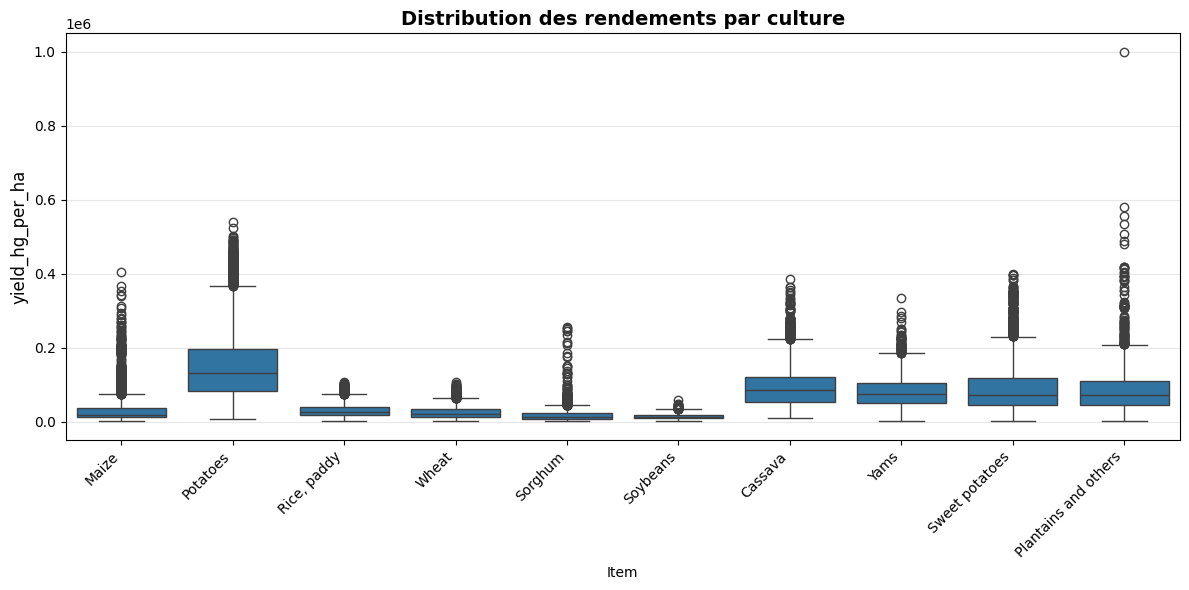

In [13]:
# Boxplot PAR CULTURE (essentiel pour données agricoles)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_rendements_fao, x='Item', y='yield_hg_per_ha')
plt.xticks(rotation=45, ha='right')
plt.ylabel('yield_hg_per_ha', fontsize=12)
plt.title('Distribution des rendements par culture', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

On observe quelques valeurs qui paraissent très haute et une particulièrement extrème (1 000 000 hg/ha pour 'Plantains and others)

In [14]:
# Identifier l'outlier extrême (1,000,000)
outlier_extreme = df_rendements_fao[df_rendements_fao['yield_hg_per_ha'] == 1000000]
print("Outlier extrême à 1,000,000 hg/ha :")
print(outlier_extreme[['Area', 'Item', 'Year', 'yield_hg_per_ha']])

Outlier extrême à 1,000,000 hg/ha :
        Area                  Item  Year  yield_hg_per_ha
27930  Kenya  Plantains and others  1964          1000000


In [15]:
# Suppression de l'outlier extrême (erreur de saisie probable)
print(f"Shape avant suppression outlier extrême : {df_rendements_fao.shape}")
df_rendements_fao = df_rendements_fao[df_rendements_fao['yield_hg_per_ha'] < 1000000].copy()
print(f"Shape après suppression outlier extrême : {df_rendements_fao.shape}")

Shape avant suppression outlier extrême : (56709, 6)
Shape après suppression outlier extrême : (56708, 6)


#### Traitement des Outliers

**Décision sur le traitement des Outliers**

**Nature des Données Agricoles Mondiales (Hétérogénéité)**

Le dataset FAO mélange des agricultures qui n'ont rien à voir :

- L'agriculture de subsistance (ex: rendement Blé ~1 tonne/ha).
- L'agriculture intensive haute technologie (ex: rendement Blé Beauce/Pays-Bas ~8-10 tonnes/ha).

**La règle standard 1.5*IQR** risque de considérer les pays très performants (France, USA, Pays-Bas) comme des outliers simplement parce qu'ils sont bien meilleurs que la moyenne mondiale. 

**👉 Conséquence** : un seuil trop bas (1.5) fausserait le modèle. Il n'apprendra jamais les hauts rendements car on les aurait supprimés.

**Distinction Erreur vs Information**

**1.5*IQR** sert souvent à nettoyer des distributions normales pour des stats descriptives.

**3*IQR** sert à détecter les anomalies de saisie (Data Entry Errors).

**Exemple 1 :** Un rendement de 50 tonnes/ha pour du blé. C'est impossible biologiquement -> C'est une erreur -> 3*IQR le supprimera.

**Exemple 2 :** Un rendement de 9 tonnes/ha. C'est exceptionnel mais possible -> C'est de l'information -> 3IQR le gardera, 1.5IQR l'aurait peut-être tué.

In [16]:
# Check avant suppression : RÈGLE : 3*IQR (au lieu de 1.5*IQR)

for culture in df_rendements_fao['Item'].unique():
    df_culture = df_rendements_fao[df_rendements_fao['Item'] == culture]
    
    Q1 = df_culture['yield_hg_per_ha'].quantile(0.25)
    Q3 = df_culture['yield_hg_per_ha'].quantile(0.75)
    IQR = Q3 - Q1
    
    # SEUIL STRICT
    limite_haute = Q3 + 3 * IQR  # Au lieu de 1.5
    
    # Supprimer UNIQUEMENT au-delà de 3*IQR
    outliers_extremes = df_culture[df_culture['yield_hg_per_ha'] > limite_haute]
    
    print(f"{culture} : {len(outliers_extremes)} outliers supprimés (> {limite_haute:.0f})")

Maize : 190 outliers supprimés (> 113744)
Potatoes : 1 outliers supprimés (> 537478)
Rice, paddy : 0 outliers supprimés (> 109510)
Wheat : 9 outliers supprimés (> 94507)
Sorghum : 60 outliers supprimés (> 66077)
Soybeans : 1 outliers supprimés (> 50025)
Cassava : 10 outliers supprimés (> 324915)
Yams : 5 outliers supprimés (> 265406)
Sweet potatoes : 36 outliers supprimés (> 341921)
Plantains and others : 45 outliers supprimés (> 305728)


In [17]:
# Affiche les pays concernés par les suppressions pour voir si on supprime des zones entières
if len(outliers_extremes) > 0:
    print(f"  -> Pays impactés : {outliers_extremes['Area'].unique()}")
    print(f"  -> Max supprimé : {outliers_extremes['yield_hg_per_ha'].max()}")
    print(f"  -> Min supprimé : {outliers_extremes['yield_hg_per_ha'].min()}")

  -> Pays impactés : ['Belize' 'El Salvador' 'Guatemala' 'Sri Lanka' 'Suriname']
  -> Max supprimé : 578976
  -> Min supprimé : 306667


Ces pays ne sont pas connus pour une agriculture super-intensive qui écraserait les rendements européens ou américains. Il s'agit très probablement d'erreurs de saisie à la source (ex: confusion entre lbs/acres et kg/ha, ou erreur de virgule, ou rapport de la production totale au lieu du rendement).

In [18]:
# --- NETTOYAGE EFFECTIF DES OUTLIERS (3*IQR) ---

print(f"Shape avant nettoyage : {df_rendements_fao.shape}")

# Liste pour stocker les numéros de lignes (index) à supprimer
indices_a_supprimer = []

for culture in df_rendements_fao['Item'].unique():
    # On isole la culture
    df_culture = df_rendements_fao[df_rendements_fao['Item'] == culture]
    
    # Calcul des bornes
    Q1 = df_culture['yield_hg_per_ha'].quantile(0.25)
    Q3 = df_culture['yield_hg_per_ha'].quantile(0.75)
    IQR = Q3 - Q1
    limite_haute = Q3 + 3 * IQR
    
    # Identification des outliers
    outliers = df_culture[df_culture['yield_hg_per_ha'] > limite_haute]
    
    if len(outliers) > 0:
        print(f"❌ {culture} : {len(outliers)} lignes identifiées pour suppression (Seuil > {limite_haute:.0f})")
        # On ajoute les INDEX de ces lignes à notre liste noire
        indices_a_supprimer.extend(outliers.index.tolist())

# --- NETTOYAGE ---
if len(indices_a_supprimer) > 0:
    df_rendements_fao = df_rendements_fao.drop(indices_a_supprimer)
    print(f"\n✅ Suppression effectuée. {len(indices_a_supprimer)} lignes retirées.")
else:
    print("\n✅ Aucune suppression nécessaire.")

print(f"Shape après nettoyage : {df_rendements_fao.shape}")

Shape avant nettoyage : (56708, 6)
❌ Maize : 190 lignes identifiées pour suppression (Seuil > 113744)
❌ Potatoes : 1 lignes identifiées pour suppression (Seuil > 537478)
❌ Wheat : 9 lignes identifiées pour suppression (Seuil > 94507)
❌ Sorghum : 60 lignes identifiées pour suppression (Seuil > 66077)
❌ Soybeans : 1 lignes identifiées pour suppression (Seuil > 50025)
❌ Cassava : 10 lignes identifiées pour suppression (Seuil > 324915)
❌ Yams : 5 lignes identifiées pour suppression (Seuil > 265406)
❌ Sweet potatoes : 36 lignes identifiées pour suppression (Seuil > 341921)
❌ Plantains and others : 45 lignes identifiées pour suppression (Seuil > 305728)

✅ Suppression effectuée. 357 lignes retirées.
Shape après nettoyage : (56351, 6)


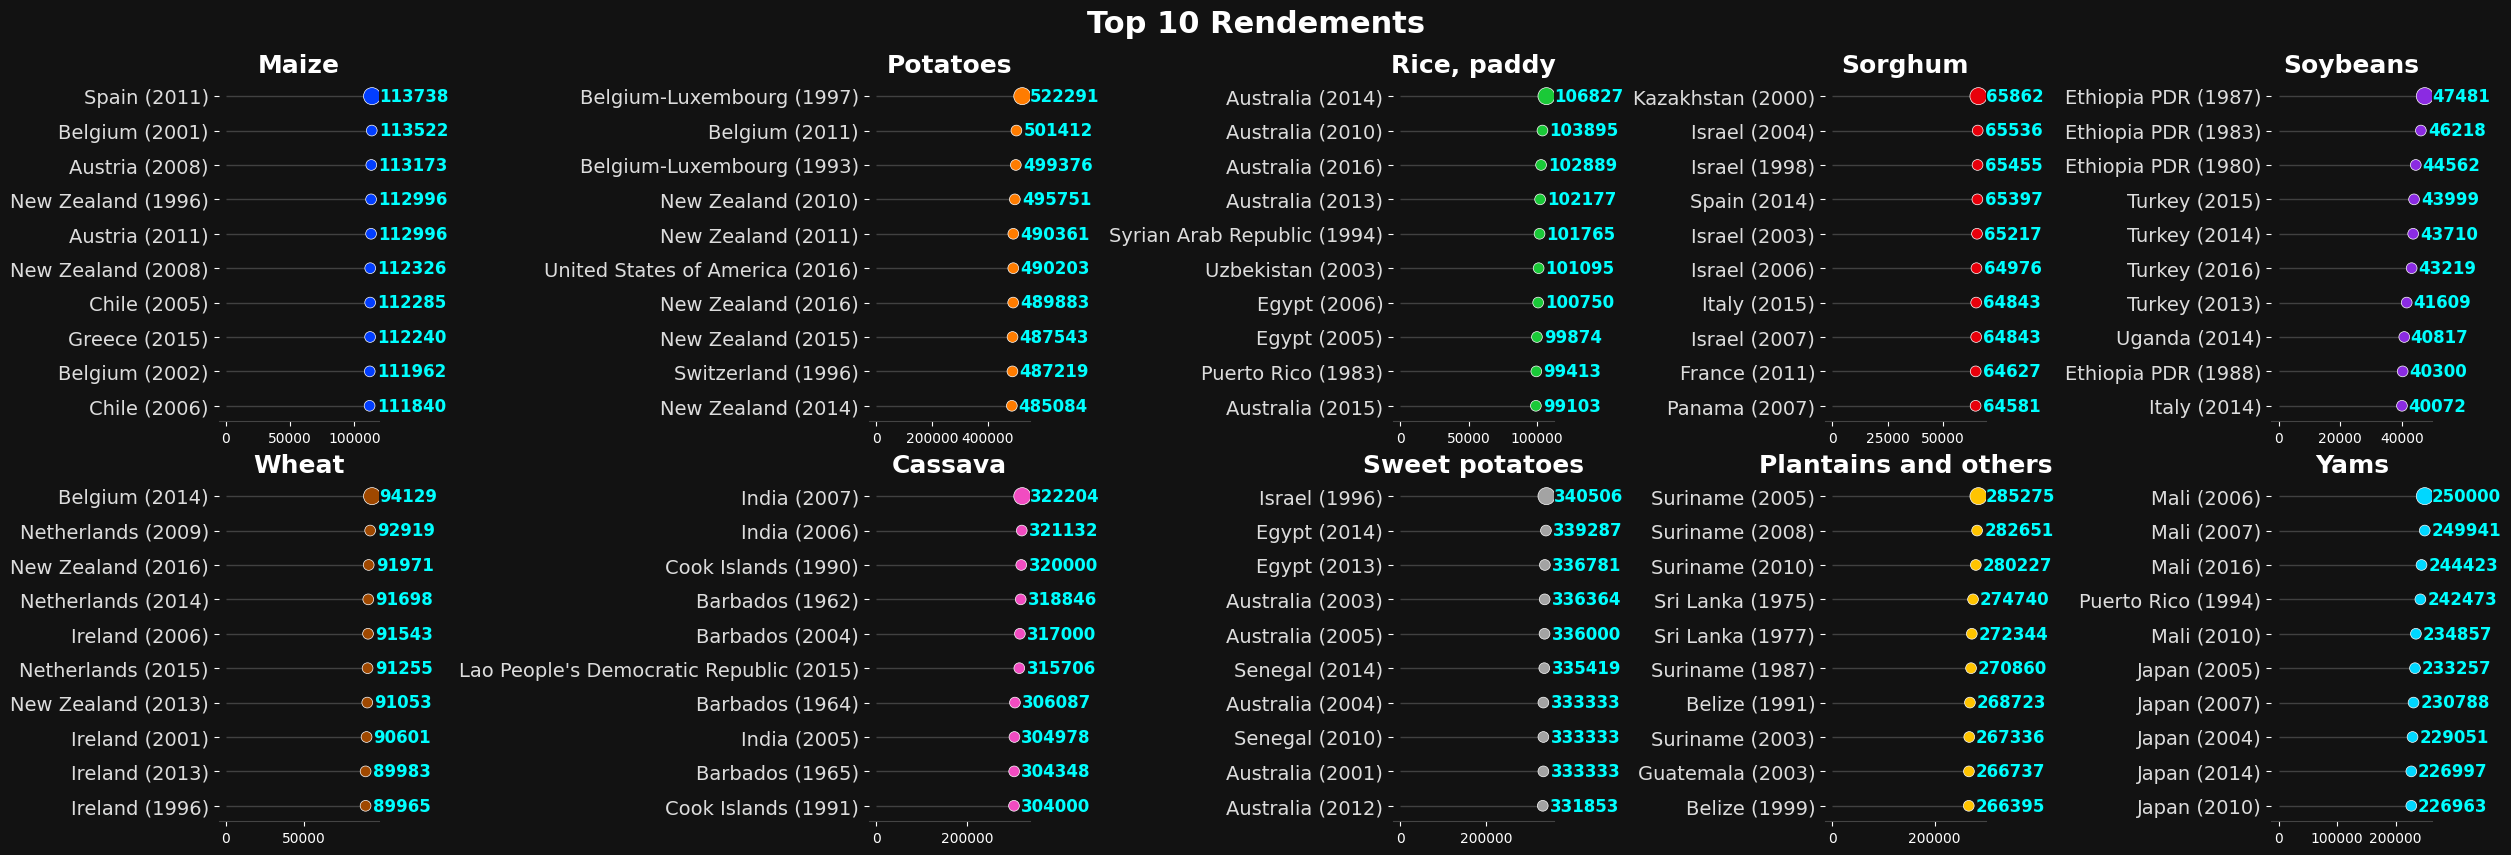

In [19]:
# Visualisation des top 10 par culture
plt.style.use('dark_background') # La commande magique qui inverse tout

# Paramètres globaux pour affiner le look (Police blanche, fond gris pro)
plt.rcParams.update({
    "figure.facecolor": "#121212",  # Fond de la page (presque noir)
    "axes.facecolor": "#121212",    # Fond des graphiques
    "grid.color": "#444444",        # Grille discrète
    "font.family": "sans-serif"
})

# Liste des cultures
cultures_list = ['Maize', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 
                 'Wheat', 'Cassava', 'Sweet potatoes', 'Plantains and others', 'Yams']

# CRÉATION DE LA GRILLE
# On garde les dimensions compactes que tu aimais
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(25, 8), constrained_layout=True)
axes = axes.flatten()

# Palette "Spectral" ou "Cool" qui ressort super bien sur le noir
colors = sns.color_palette("bright", len(cultures_list))

for i, culture in enumerate(cultures_list):
    ax = axes[i]
    
    # 1. Données (Triées)
    top10 = df_rendements_fao[df_rendements_fao['Item'] == culture].nlargest(10, 'yield_hg_per_ha').sort_values('yield_hg_per_ha', ascending=True)
    labels = top10['Area'] + " (" + top10['Year'].astype(str) + ")"
    values = top10['yield_hg_per_ha']
    
    # 2. Le Lollipop Chart (Version Dark)
    # Tiges : Blanches mais transparentes pour être discrètes
    ax.hlines(y=range(len(labels)), xmin=0, xmax=values, color='white', alpha=0.2, linewidth=1)
    
    # Points : On garde la logique de taille, mais avec des couleurs vives
    sizes = [150 if x == values.max() else 60 for x in values]
    ax.scatter(values, range(len(labels)), color=colors[i], s=sizes, alpha=1, zorder=3, edgecolors='white', linewidth=0.5)
    
    # 3. Textes et Axes
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=14, color='#DDDDDD') # Gris clair pour ne pas agresser
    ax.set_title(f"{culture}", fontweight='bold', fontsize=18, color='white') # Titre blanc pur
    ax.set_xlabel("") # On enlève le label X pour gagner de la place
    
    # Suppression totale des bordures pour un look "flottant"
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('#444444')
    
    # Data Labels (Valeurs) en couleur vive pour lisibilité
    for y, x in enumerate(values):
        # Le texte est placé un peu à droite (+5%), en Cyan ou Blanc
        ax.text(x + (x*0.05), y, f"{x:.0f}", va='center', fontsize=12, color='#00FFFF', fontweight='bold')

# Titre global "Néon"
fig.suptitle("Top 10 Rendements", fontsize=22, fontweight='bold', color='white', y=1.05)

plt.show()
plt.style.use('default')

#### Conclusions de l'analyse des outliers
**1. Méthodologie : Tukey's Far Outliers**
Nous avons analysé la distribution des rendements en appliquant un seuil strict ($Seuil = Q3 + 3 \times IQR$). L'objectif était d'identifier les erreurs de saisie manifestes (valeurs biologiquement impossibles) sans supprimer les données issues de l'agriculture intensive performante.

**2. Analyse Qualitative des "Top 10" (Post-Nettoyage)**

L'inspection des rendements après filtrage statistique (**3*IQR**) valide l'efficacité de notre stratégie de nettoyage :

* **Correction des Aberrations (Sanity Check) :** Les anomalies manifestes ont été éliminées avec succès.
    * *Le cas du Maïs/Sorgho :* Les valeurs incohérentes en milieu désertique (Jordanie, EAU > 20-40 t/ha, probablement issues de serres expérimentales ou d'erreurs d'unité) ont disparu. Le classement est désormais dominé par des acteurs majeurs de l'agriculture intensive (Espagne, USA, Nouvelle-Zélande) avec des rendements réalistes (~11 t/ha).
    * *Le cas du Blé :* Le filtre a légèrement écrêté les records extrêmes (Irlande) pour stabiliser la distribution autour de ~9.5 t/ha (Belgique, Pays-Bas), standard de l'agriculture de haute précision.

* **Préservation de la Physique des Cultures :**
    * Le filtre a correctement identifié que les rendements très élevés des tubercules (**Pommes de terre, Manioc** : 30 à 50 t/ha) ne sont pas des erreurs, mais une réalité biologique (produits riches en eau et lourds). Ils ont été conservés intégralement.

**3. Stratégie de Conservation**
La fusion à venir avec le dataset Crop Yield restreindra notre périmètre aux 4 cultures communes : **Wheat, Maize, Rice, Soybean**.
Cette restriction agit comme un filtre qualité naturel, éliminant de facto les cultures les plus sujettes aux erreurs de classification (comme le Sorgho ou les Tubercules tropicaux).

✅ **Décision :** Aucune suppression massive n'est appliquée à ce stade. Les datasets sont considérés comme **sains et cohérents** pour l'étape de fusion.

## Données de rendements selon les facteurs climatiques 
Source : yield_df.csv - Rendements avec facteurs climatiques (1990-2013)

### Chargement et Vue d'ensemble

In [20]:
df_rendements_agro = pd.read_csv(DONNEES_AGRO_CLIMATIQUES / "yield_df.csv")
print(f"Shape : {df_rendements_agro.shape}")
df_rendements_agro.head()

Shape : (28242, 8)


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [21]:
df_rendements_agro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB


On voir les stats des valeurs continues

### Consolidation des Données : Traitement des Doublons Complexes

Contrairement au premier dataset (`yield.csv`) qui contenait des observations brutes, ce dataset est le résultat de fusions préalables entre rendements, températures, pluviométrie et pesticides.

**Problématique identifiée :**
Une analyse exploratoire préalable révèle des lignes multiples pour un même triplet `(Area, Year, Item)`. Ces doublons présentent parfois d'infimes variations (probablement dues à des calculs de virgule flottante lors des fusions précédentes), empêchant une suppression simple par `drop_duplicates()`.

**Stratégie de correction :**
Pour garantir l'unicité de chaque observation (une seule ligne par Pays/Année/Culture), nous appliquons une **agrégation par moyenne**. Cela permet de :
1. Fusionner les doublons stricts.
2. Lisser les micro-variations climatiques éventuelles.

In [22]:
print(f"Shape avant consolidation : {df_rendements_agro.shape}")

# 1. Définition des clés d'unicité (Ce qui définit une ligne unique)
cols_cles = ['Area', 'Year', 'Item']

# 2. Vérification du volume de doublons potentiels (sur les clés seulement)
doublons_cles = df_rendements_agro.duplicated(subset=cols_cles).sum()
print(f"🕵️‍♂️ Nombre d'entrées dupliquées sur les clés {cols_cles} : {doublons_cles}")

if doublons_cles > 0:
    # 3. Agrégation "Bulldozer" : On groupe par clé et on moyenne les valeurs numériques
    # Cela gère à la fois les doublons parfaits et les quasi-doublons
    df_rendements_agro = df_rendements_agro.groupby(cols_cles).mean().reset_index()
    
    print(f"✅ Consolidation effectuée par moyenne.")
    print(f"Shape après consolidation : {df_rendements_agro.shape}")
else:
    print("✅ Aucune consolidation nécessaire (les clés sont uniques).")

# Petit sanity check pour vérifier qu'on n'a pas perdu de colonnes
print("Colonnes restantes :", df_rendements_agro.columns.tolist())

Shape avant consolidation : (28242, 8)
🕵️‍♂️ Nombre d'entrées dupliquées sur les clés ['Area', 'Year', 'Item'] : 15112
✅ Consolidation effectuée par moyenne.
Shape après consolidation : (13130, 8)
Colonnes restantes : ['Area', 'Year', 'Item', 'Unnamed: 0', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


In [23]:
df_rendements_agro[['average_rain_fall_mm_per_year', 
    'pesticides_tonnes', 'avg_temp']].describe()

,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,13130.000000,13130.000000,13130.000000
mean,1157.238766,14838.697886,19.836531
std,743.622488,33652.454670,6.658083
min,51.000000,0.040000,1.300000
25%,608.000000,264.530000,15.670000
50%,1083.000000,2172.200000,20.620000
75%,1651.000000,13335.220000,25.780000
max,3240.000000,367778.000000,30.420000


Valeurs assez disparates mais comme pour le dataset précédent, on va les étudier par culture, voire par pays

Valeurs manquantes :
Area                             0
Year                             0
Item                             0
Unnamed: 0                       0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64


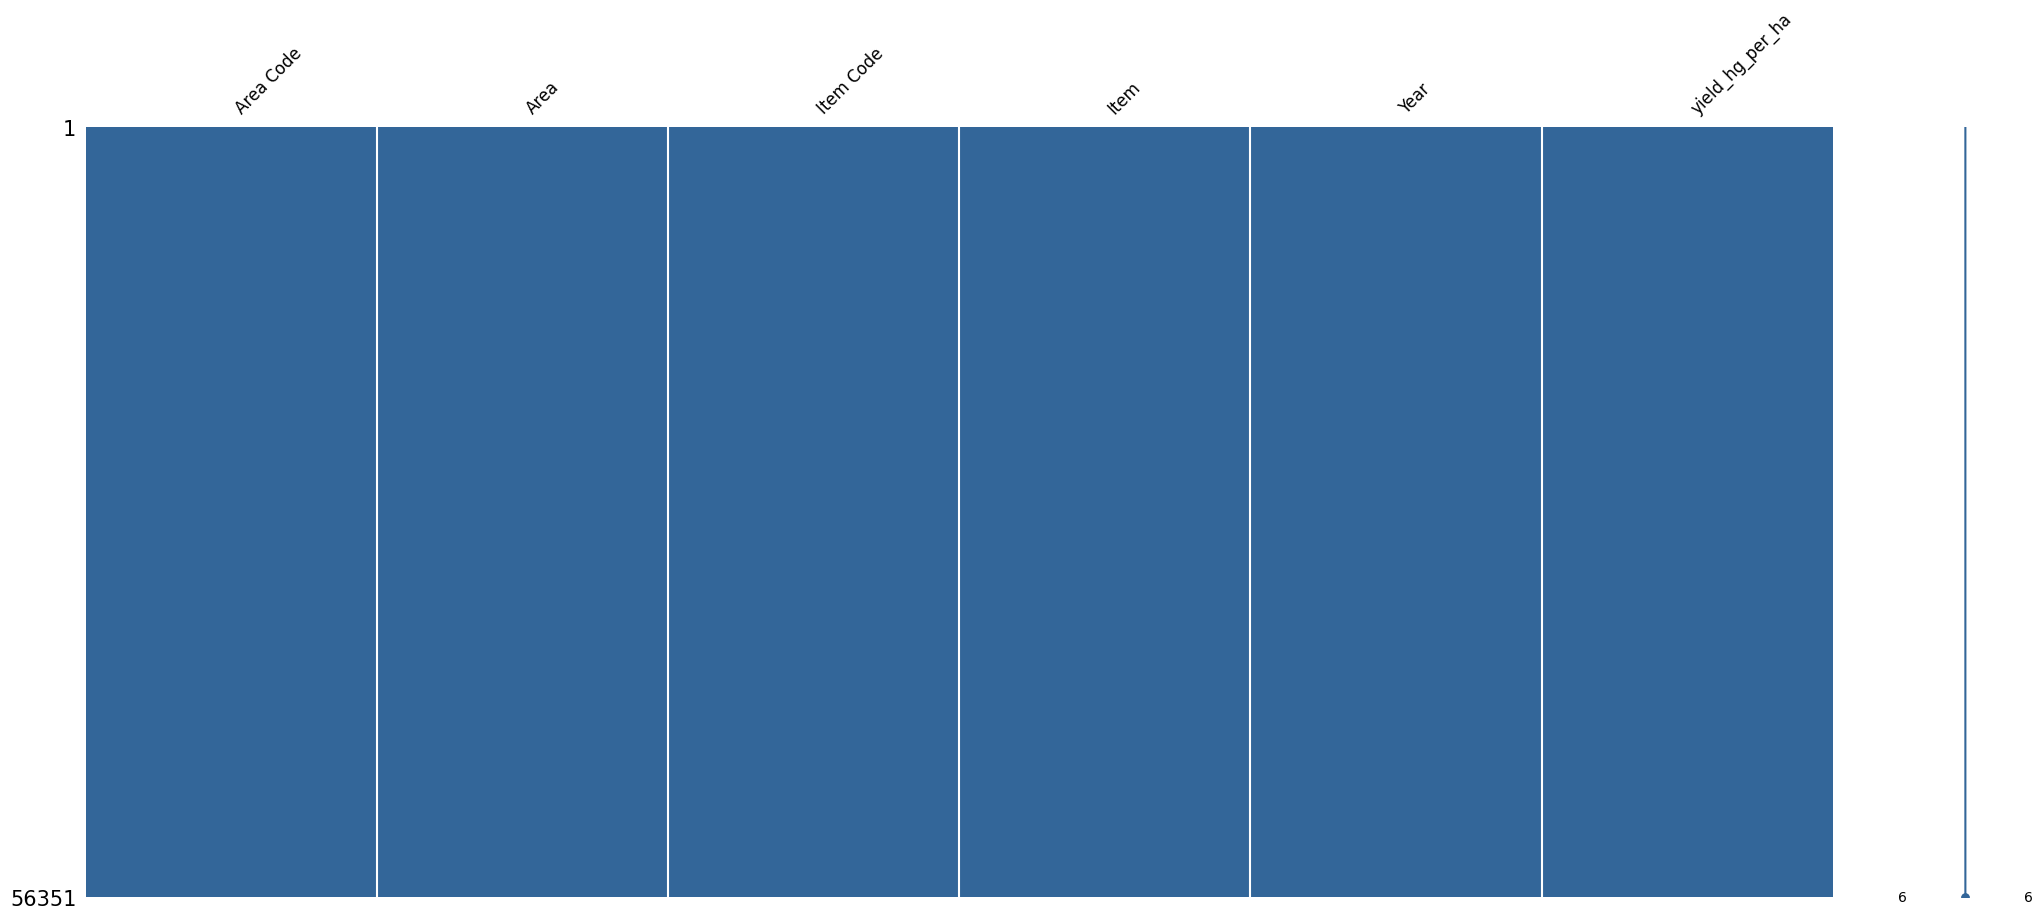

In [24]:
# Valeurs manquantes
print("Valeurs manquantes :")
print(df_rendements_agro.isnull().sum())
plt.style.context('seaborn-white') # Style propre et blanc
msno.matrix(
        df_rendements_fao, 
        color=(0.2, 0.4, 0.6), # Code RGB (Bleu acier sympa)
        fontsize=12
    )

plt.show()
plt.style.use('default')

Aucune valeur manquante. On va renommer la colonne cible rendement avec le même nom que le précédent dataset. 

In [25]:
# Standardisation nom colonne rendement
df_rendements_agro.rename(columns={'hg/ha_yield': 'yield_hg_per_ha'}, inplace=True)

### Analyse des outliers

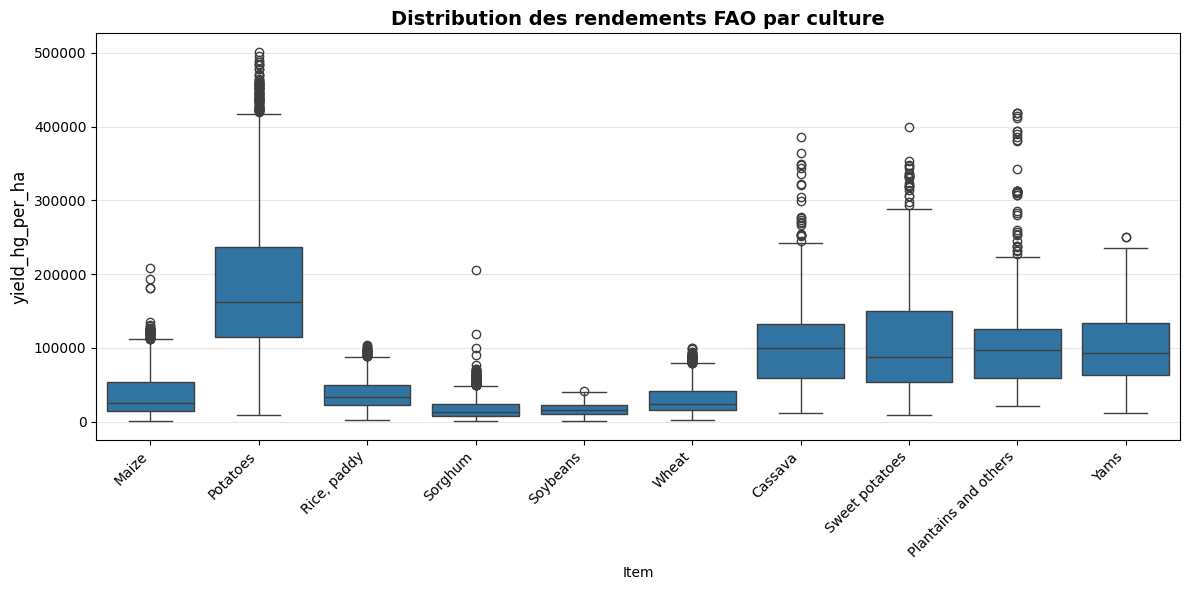

In [26]:
# Boxplot PAR CULTURE (essentiel pour données agricoles)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_rendements_agro, x='Item', y='yield_hg_per_ha')
plt.xticks(rotation=45, ha='right')
plt.ylabel('yield_hg_per_ha', fontsize=12)
plt.title('Distribution des rendements FAO par culture', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Observation :** Les rendements varient énormément selon les cultures (Potatoes ~300K vs Sorghum ~15K).

In [27]:
# Check des outliers avant suppression : RÈGLE : 3*IQR (au lieu de 1.5*IQR)
# = Supprimer UNIQUEMENT les outliers EXTRÊMES

for culture in df_rendements_agro['Item'].unique():
    df_culture = df_rendements_agro[df_rendements_agro['Item'] == culture]
    
    Q1 = df_culture['yield_hg_per_ha'].quantile(0.25)
    Q3 = df_culture['yield_hg_per_ha'].quantile(0.75)
    IQR = Q3 - Q1
    
    # SEUIL STRICT
    limite_haute = Q3 + 3 * IQR  # Au lieu de 1.5
    
    # Supprimer UNIQUEMENT au-delà de 3*IQR
    outliers_extremes_climat = df_culture[df_culture['yield_hg_per_ha'] > limite_haute]
    
    print(f"{culture} : {len(outliers_extremes_climat)} outliers supprimés (> {limite_haute:.0f})")

Maize : 4 outliers supprimés (> 170536)
Potatoes : 0 outliers supprimés (> 599009)
Rice, paddy : 0 outliers supprimés (> 127119)
Sorghum : 5 outliers supprimés (> 74928)
Soybeans : 0 outliers supprimés (> 58855)
Wheat : 0 outliers supprimés (> 117477)
Cassava : 2 outliers supprimés (> 352904)
Sweet potatoes : 0 outliers supprimés (> 437608)
Plantains and others : 12 outliers supprimés (> 323489)
Yams : 0 outliers supprimés (> 343456)


In [28]:
# Affiche les pays concernés par les suppressions pour voir si on supprime des zones entières
if len(outliers_extremes_climat) > 0:
    print(f"  -> Pays impactés : {outliers_extremes_climat['Area'].unique()}")
    print(f"  -> Max supprimé : {outliers_extremes_climat['yield_hg_per_ha'].max()}")
    print(f"  -> Min supprimé : {outliers_extremes_climat['yield_hg_per_ha'].min()}")

Aucun pays entier impacté

In [29]:
# --- NETTOYAGE EFFECTIF DES OUTLIERS (3*IQR) ---

print(f"Shape avant nettoyage : {df_rendements_agro.shape}")

# Liste pour stocker les numéros de lignes (index) à supprimer
indices_a_supprimer = []

for culture in df_rendements_agro['Item'].unique():
    # On isole la culture
    df_culture = df_rendements_agro[df_rendements_agro['Item'] == culture]
    
    # Calcul des bornes
    Q1 = df_culture['yield_hg_per_ha'].quantile(0.25)
    Q3 = df_culture['yield_hg_per_ha'].quantile(0.75)
    IQR = Q3 - Q1
    limite_haute = Q3 + 3 * IQR
    
    # Identification des outliers
    outliers = df_culture[df_culture['yield_hg_per_ha'] > limite_haute]
    
    if len(outliers) > 0:
        print(f"❌ {culture} : {len(outliers)} lignes identifiées pour suppression (Seuil > {limite_haute:.0f})")
        # On ajoute les INDEX de ces lignes à notre liste noire
        indices_a_supprimer.extend(outliers.index.tolist())

# --- NETTOYAGE ---
if len(indices_a_supprimer) > 0:
    df_rendements_agro = df_rendements_agro.drop(indices_a_supprimer)
    print(f"\n✅ Suppression effectuée. {len(indices_a_supprimer)} lignes retirées.")
else:
    print("\n✅ Aucune suppression nécessaire.")

print(f"Shape après nettoyage : {df_rendements_agro.shape}")

Shape avant nettoyage : (13130, 8)
❌ Maize : 4 lignes identifiées pour suppression (Seuil > 170536)
❌ Sorghum : 5 lignes identifiées pour suppression (Seuil > 74928)
❌ Cassava : 2 lignes identifiées pour suppression (Seuil > 352904)
❌ Plantains and others : 12 lignes identifiées pour suppression (Seuil > 323489)

✅ Suppression effectuée. 23 lignes retirées.
Shape après nettoyage : (13107, 8)


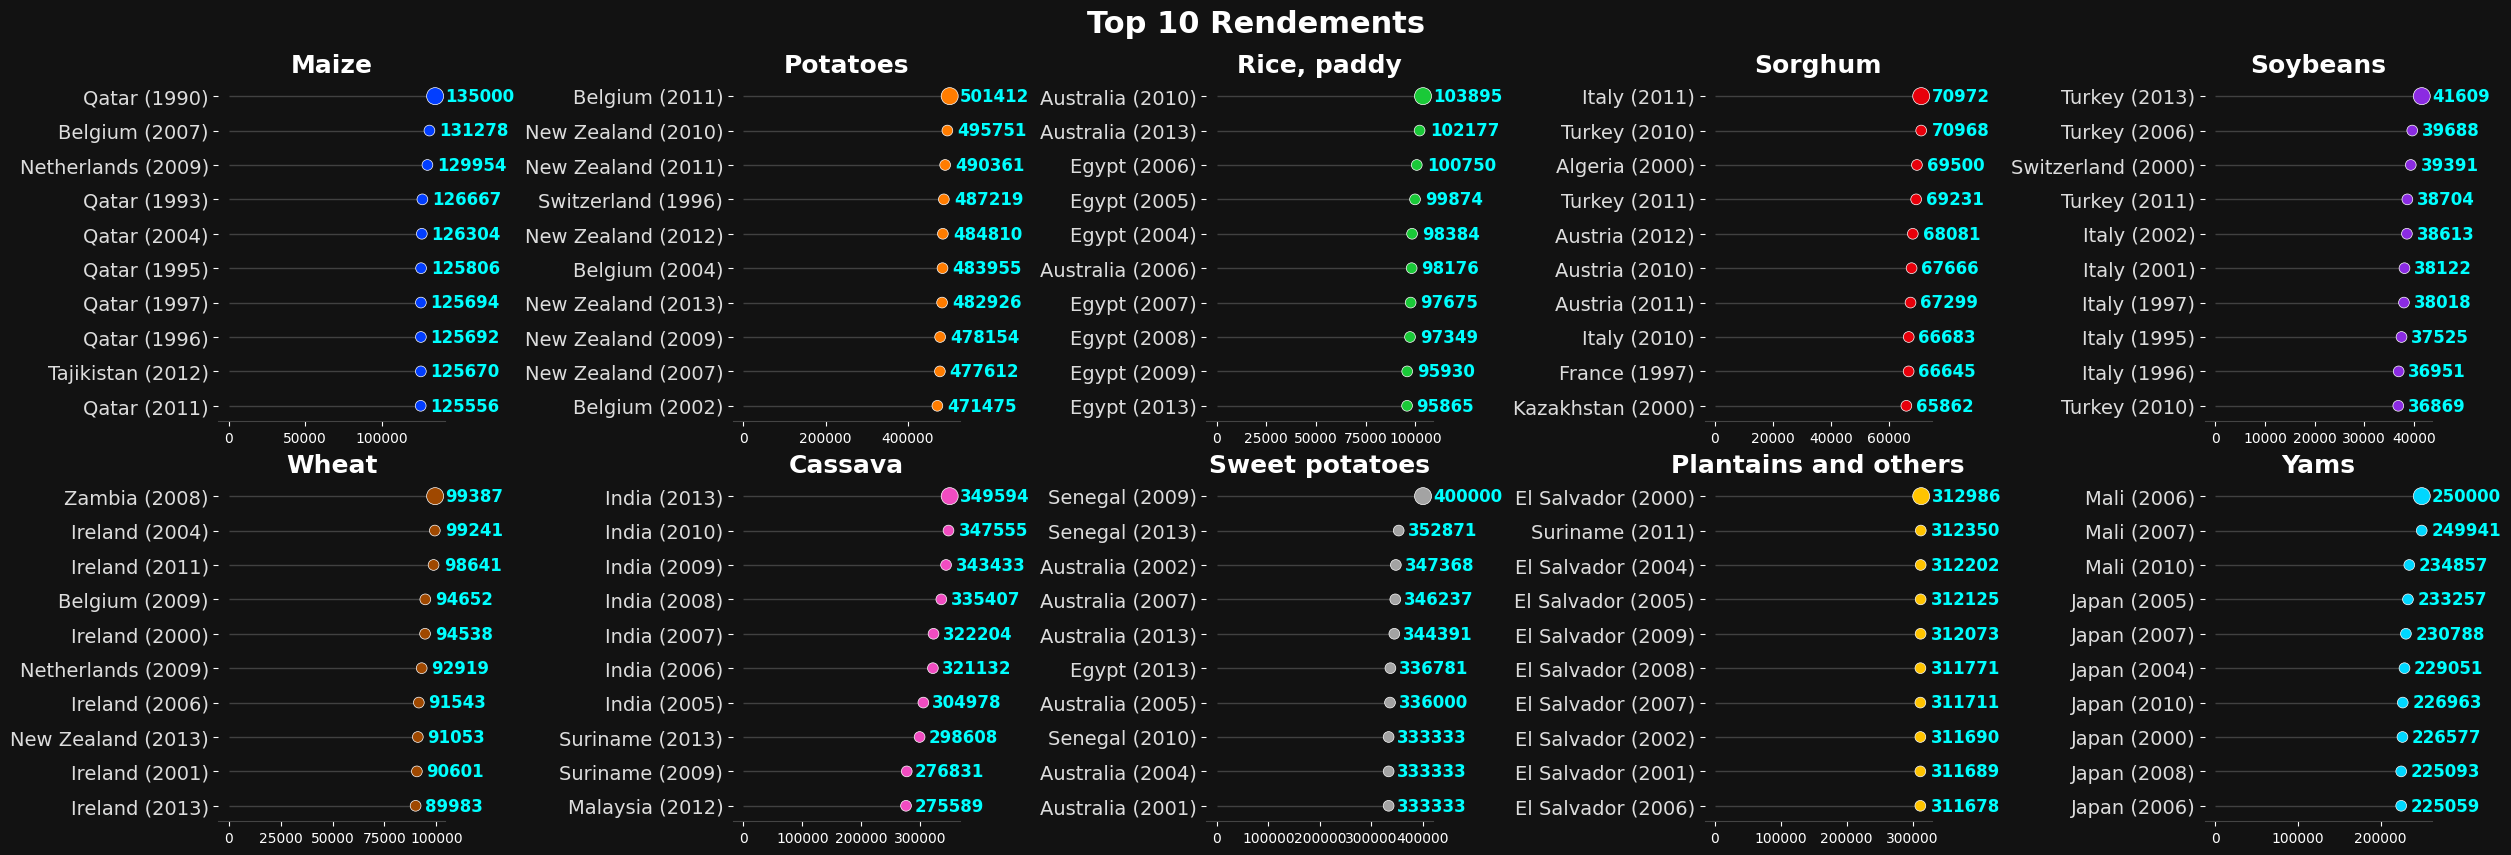

In [30]:
# Visualisation des top 10 par culture
plt.style.use('dark_background') # La commande magique qui inverse tout

# Paramètres globaux pour affiner le look (Police blanche, fond gris pro)
plt.rcParams.update({
    "figure.facecolor": "#121212",  # Fond de la page (presque noir)
    "axes.facecolor": "#121212",    # Fond des graphiques
    "grid.color": "#444444",        # Grille discrète
    "font.family": "sans-serif"
})

# Liste des cultures
cultures_list = ['Maize', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 
                 'Wheat', 'Cassava', 'Sweet potatoes', 'Plantains and others', 'Yams']

# CRÉATION DE LA GRILLE
# On garde les dimensions compactes que tu aimais
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(25, 8), constrained_layout=True)
axes = axes.flatten()

# Palette "Spectral" ou "Cool" qui ressort super bien sur le noir
colors = sns.color_palette("bright", len(cultures_list))

for i, culture in enumerate(cultures_list):
    ax = axes[i]
    
    # 1. Données (Triées)
    top10 = df_rendements_agro[df_rendements_agro['Item'] == culture].nlargest(10, 'yield_hg_per_ha').sort_values('yield_hg_per_ha', ascending=True)
    labels = top10['Area'] + " (" + top10['Year'].astype(str) + ")"
    values = top10['yield_hg_per_ha']
    
    # 2. Le Lollipop Chart (Version Dark)
    # Tiges : Blanches mais transparentes pour être discrètes
    ax.hlines(y=range(len(labels)), xmin=0, xmax=values, color='white', alpha=0.2, linewidth=1)
    
    # Points : On garde la logique de taille, mais avec des couleurs vives
    sizes = [150 if x == values.max() else 60 for x in values]
    ax.scatter(values, range(len(labels)), color=colors[i], s=sizes, alpha=1, zorder=3, edgecolors='white', linewidth=0.5)
    
    # 3. Textes et Axes
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=14, color='#DDDDDD') # Gris clair pour ne pas agresser
    ax.set_title(f"{culture}", fontweight='bold', fontsize=18, color='white') # Titre blanc pur
    ax.set_xlabel("") # On enlève le label X pour gagner de la place
    
    # Suppression totale des bordures pour un look "flottant"
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('#444444')
    
    # Data Labels (Valeurs) en couleur vive pour lisibilité
    for y, x in enumerate(values):
        # Le texte est placé un peu à droite (+5%), en Cyan ou Blanc
        ax.text(x + (x*0.05), y, f"{x:.0f}", va='center', fontsize=12, color='#00FFFF', fontweight='bold')

# Titre global "Néon"
fig.suptitle("Top 10 Rendements", fontsize=22, fontweight='bold', color='white', y=1.05)

plt.show()
plt.style.use('default')

### Synthèse sur le Dataset Agrégé (Yield + Climat)

**1. Intégrité Structurelle (Le Problème des Doublons) :**
L'analyse exploratoire a révélé une corruption majeure des données (ex: duplication systématique des lignes pour l'Australie ou l'Égypte).
* *Diagnostic :* Ces doublons sont des artefacts de jointure (produit cartésien) issus d'une mauvaise fusion préalable des fichiers bruts.
* *Correction :* Une agrégation stricte (`groupby().mean()`) a été appliquée pour restaurer l'unicité de la clé primaire (Pays/Année/Culture).

**2. Cohérence des Valeurs :**
Après dédoublonnage, les distributions de rendement (t/ha) sont cohérentes avec les observations du dataset FAO brut. Aucune perte d'information n'a été constatée.

**✅ Verdict & Stratégie :**
Bien que ce dataset ait été nettoyé ("réparé"), la présence initiale de tant d'erreurs structurelles nous incite à la prudence.
**Décision :** Nous privilégierons la **reconstruction complète** du dataset final à partir des sources brutes nettoyées individuellement (Pluie, Temp, Pest, Yield), plutôt que de nous appuyer sur ce fichier pré-agrégé douteux.

## Données sur les pesticides

### Chargement et Vue d'ensemble

In [31]:
df_pesticides = pd.read_csv(DONNEES_AGRO_CLIMATIQUES / "pesticides.csv")
print(f"Shape : {df_pesticides.shape}")
df_pesticides.head()

Shape : (4349, 7)


,Domain,Area,Element,Item,Year,Unit,Value
0,Pesticides Use,Albania,Use,Pesticides (total),1990,tonnes of active ingredients,121.0
1,Pesticides Use,Albania,Use,Pesticides (total),1991,tonnes of active ingredients,121.0
2,Pesticides Use,Albania,Use,Pesticides (total),1992,tonnes of active ingredients,121.0
3,Pesticides Use,Albania,Use,Pesticides (total),1993,tonnes of active ingredients,121.0
4,Pesticides Use,Albania,Use,Pesticides (total),1994,tonnes of active ingredients,201.0


In [32]:
df_pesticides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4349 entries, 0 to 4348
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Domain   4349 non-null   object 
 1   Area     4349 non-null   object 
 2   Element  4349 non-null   object 
 3   Item     4349 non-null   object 
 4   Year     4349 non-null   int64  
 5   Unit     4349 non-null   object 
 6   Value    4349 non-null   float64
dtypes: float64(1), int64(1), object(5)
memory usage: 238.0+ KB


### Nettoyage des colonnes et vérification des doublons et des valeurs manquantes

In [33]:
# 1. Identifier les colonnes constantes
cols_constantes = df_pesticides.columns[df_pesticides.nunique() <= 1]
print(f"🗑️ Colonnes inutiles supprimées : {list(cols_constantes)}")

# 2. Les supprimer
df_pesticides = df_pesticides.drop(columns=cols_constantes)

🗑️ Colonnes inutiles supprimées : ['Domain', 'Element', 'Item', 'Unit']


In [34]:
# Renommer Value → pesticides_tonnes
df_pesticides.rename(columns={'Value': 'pesticides_tonnes'}, inplace=True)
print("Colonnes après renommage :")
print(df_pesticides.columns.tolist())

Colonnes après renommage :
['Area', 'Year', 'pesticides_tonnes']


In [35]:
print(f"Shape avant consolidation : {df_pesticides.shape}")

# 1. Définition des clés d'unicité (Ce qui définit une ligne unique)
cols_cles = ['Area', 'Year']

# 2. Vérification du volume de doublons potentiels (sur les clés seulement)
doublons_cles = df_pesticides.duplicated(subset=cols_cles).sum()
print(f"🕵️‍♂️ Nombre d'entrées dupliquées sur les clés {cols_cles} : {doublons_cles}")

if doublons_cles > 0:
    # 3. Agrégation "Bulldozer" : On groupe par clé et on moyenne les valeurs numériques
    # Cela gère à la fois les doublons parfaits et les quasi-doublons
    df_pesticides =df_pesticides.groupby(cols_cles).mean().reset_index()
    
    print(f"✅ Consolidation effectuée par moyenne.")
    print(f"Shape après consolidation : {df_pesticides.shape}")
else:
    print("✅ Aucune consolidation nécessaire (les clés sont uniques).")

# Petit sanity check pour vérifier qu'on n'a pas perdu de colonnes
print("Colonnes restantes :", df_pesticides.columns.tolist())

Shape avant consolidation : (4349, 3)
🕵️‍♂️ Nombre d'entrées dupliquées sur les clés ['Area', 'Year'] : 0
✅ Aucune consolidation nécessaire (les clés sont uniques).
Colonnes restantes : ['Area', 'Year', 'pesticides_tonnes']


Valeurs manquantes :
Area                 0
Year                 0
pesticides_tonnes    0
dtype: int64


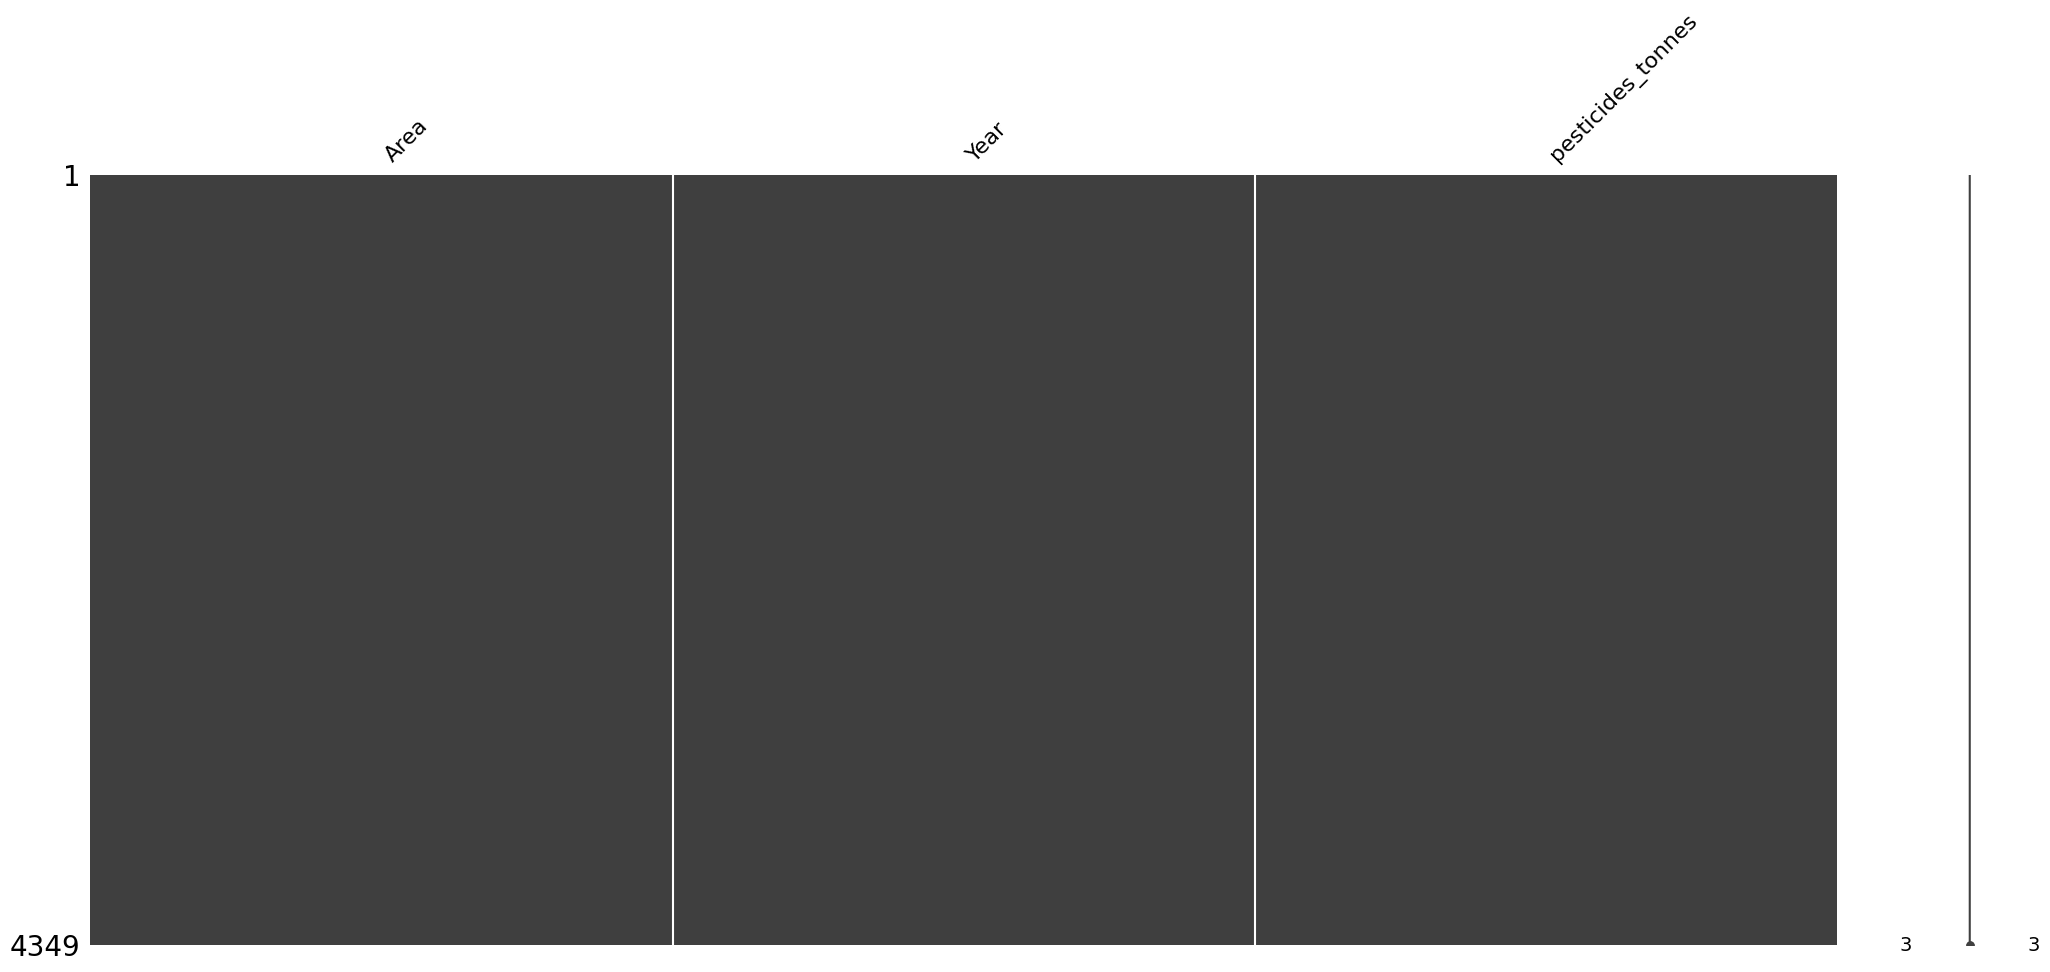

In [36]:
# Valeurs manquantes
print("Valeurs manquantes :")
print(df_pesticides.isnull().sum())
msno.matrix(df_pesticides)
plt.show()

### Informations clés

In [37]:
print("=" * 50)
print("INFORMATIONS CLÉS - df_pesticides")
print("=" * 50)
print(f"Nombre de pays : {df_pesticides['Area'].nunique()}")
print(f"Période : {df_pesticides['Year'].min()} - {df_pesticides['Year'].max()}")
print(f"Statistiques pesticides_tonnes :")
print(df_pesticides['pesticides_tonnes'].describe())
print(f"Shape finale : {df_pesticides.shape}")

INFORMATIONS CLÉS - df_pesticides
Nombre de pays : 168
Période : 1990 - 2016
Statistiques pesticides_tonnes :
count    4.349000e+03
mean     2.030334e+04
std      1.177362e+05
min      0.000000e+00
25%      9.300000e+01
50%      1.137560e+03
75%      7.869000e+03
max      1.807000e+06
Name: pesticides_tonnes, dtype: float64
Shape finale : (4349, 3)


Text(0.5, 1.0, 'Usage pesticides - TOP 15 pays')

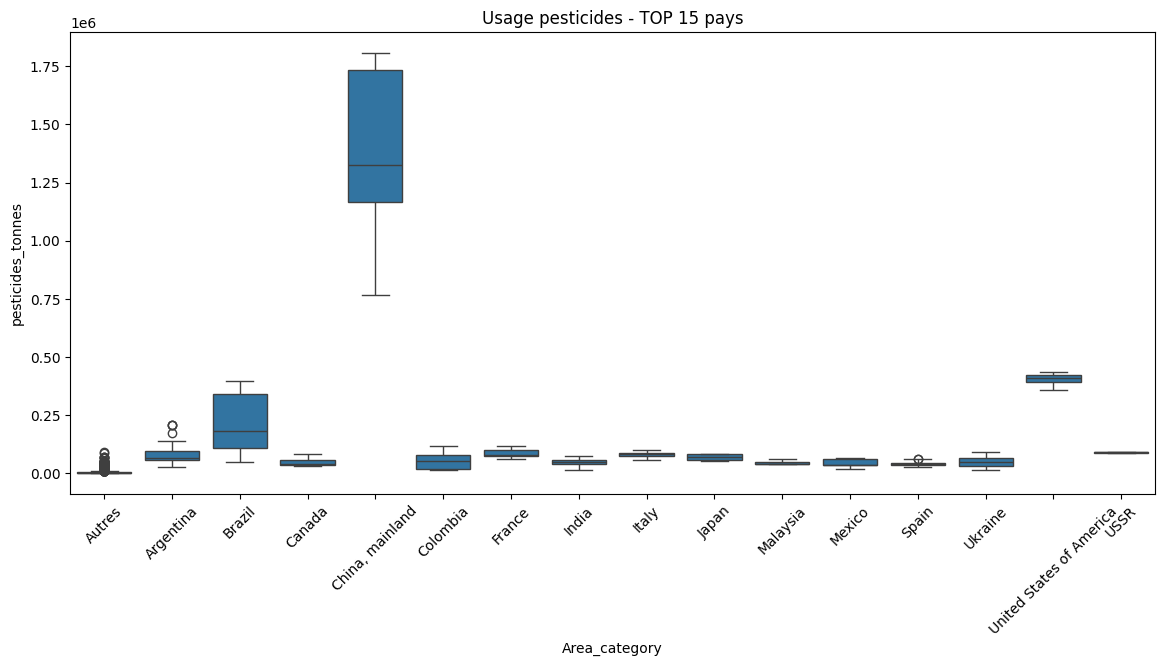

In [38]:
# 1. Identifier TOP 15 pays
top15 = df_pesticides.groupby('Area')['pesticides_tonnes'].mean().nlargest(15)

# 2. Créer catégorie "Autres"
df_pesticides['Area_category'] = df_pesticides['Area'].apply(
    lambda x: x if x in top15.index else 'Autres'
)

# 3. Boxplot par catégorie
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_pesticides, x='Area_category', y='pesticides_tonnes')
plt.xticks(rotation=45)
plt.title('Usage pesticides - TOP 15 pays')

In [39]:
# Statistiques descriptives par pays
stats_pesticides = df_pesticides.groupby('Area')['pesticides_tonnes'].agg([
    'count', 'mean', 'median', 'std', 'max'
]).sort_values('mean', ascending=False)

print("TOP 10 pays (usage moyen) :")
print(stats_pesticides.head(10))

# → Identifier si Chine, USA, Brésil, Inde en tête = NORMAL

TOP 10 pays (usage moyen) :
                          count          mean      median            std  \
Area                                                                       
China, mainland              27  1.377587e+06  1325226.00  350780.830562   
United States of America     27  4.066033e+05   407779.20   19601.925928   
Brazil                       27  2.100575e+05   182446.00  118515.400410   
USSR                          2  8.920000e+04    89200.00    4242.640687   
Argentina                    27  8.333572e+04    64568.95   55643.170138   
France                       27  8.327432e+04    78577.00   15874.236019   
Italy                        27  7.826321e+04    80454.00   11083.404115   
Japan                        27  6.826507e+04    67869.72   11413.294411   
Colombia                     27  5.486039e+04    52883.00   30837.881027   
India                        27  4.898567e+04    49157.00   14436.438764   

                                 max  
Area                

### Analyse visuelle des outliers - Chine vs Reste du monde

In [40]:
# Séparer les données
china_data = df_pesticides[df_pesticides['Area'] == 'China, mainland']['pesticides_tonnes']
other_data = df_pesticides[df_pesticides['Area'] != 'China, mainland']['pesticides_tonnes']
abs# Statistiques comparatives
print(f"\n📈 Statistiques comparatives :")
print(f"Chine - Médiane : {china_data.median():,.0f} tonnes")
print(f"Chine - Max : {china_data.max():,.0f} tonnes")
print(f"Reste - Médiane : {other_data.median():,.0f} tonnes")
print(f"Reste - Max : {other_data.max():,.0f} tonnes")



📈 Statistiques comparatives :
Chine - Médiane : 1,325,226 tonnes
Chine - Max : 1,807,000 tonnes
Reste - Médiane : 1,094 tonnes
Reste - Max : 434,541 tonnes


In [41]:
print("\n✅ DÉCISION : Outliers Chine conservés")
print("Justification : Outlier structurel (1er producteur agricole mondial)")


✅ DÉCISION : Outliers Chine conservés
Justification : Outlier structurel (1er producteur agricole mondial)


### Synthèse sur les Pesticides

**1. Qualité des Données :**
Le dataset brut présentait des colonnes non informatives (valeurs constantes) qui ont été supprimées. La structure temporelle est saine après agrégation préventive.

**2. Analyse des Outliers (Le Cas de la Chine) :**
La Chine présente des volumes de consommation de pesticides extrêmes (~1.8M tonnes vs médiane mondiale ~1k tonnes).
* *Interprétation :* Il s'agit d'une **Grandeur Extensive** (qui dépend de la taille du système). La Chine consomme plus car sa surface agricole est immense. Ce n'est pas une erreur de saisie.
* *Décision :* L'outlier est conservé car il reflète la réalité économique.

**⚠️ Point de Vigilance Modélisation :**
Utiliser le volume brut (Tonnes) risque d'introduire un biais de "taille de pays" dans le modèle (corrélation fallacieuse entre taille du pays et rendement).
* *Action future :* Il sera nécessaire lors du Feature Engineering de ramener cette variable à l'hectare ou d'utiliser un *RobustScaler* pour ne pas écraser les données des petits pays.

## Données sur la pluviométrie

**Source :** `rainfall.csv` - Précipitations moyennes annuelles

### Chargement et Vue d'ensemble

In [42]:
df_rainfall = pd.read_csv(DONNEES_AGRO_CLIMATIQUES / "rainfall.csv")
print(f"Shape : {df_rainfall.shape}")
df_rainfall.head()

Shape : (6727, 3)


,Area,Year,average_rain_fall_mm_per_year
0,Afghanistan,1985,327
1,Afghanistan,1986,327
2,Afghanistan,1987,327
3,Afghanistan,1989,327
4,Afghanistan,1990,327


In [43]:
df_rainfall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6727 entries, 0 to 6726
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0    Area                          6727 non-null   object
 1   Year                           6727 non-null   int64 
 2   average_rain_fall_mm_per_year  5953 non-null   object
dtypes: int64(1), object(2)
memory usage: 157.8+ KB


Valeurs manquantes :
 Area                              0
Year                               0
average_rain_fall_mm_per_year    774
dtype: int64


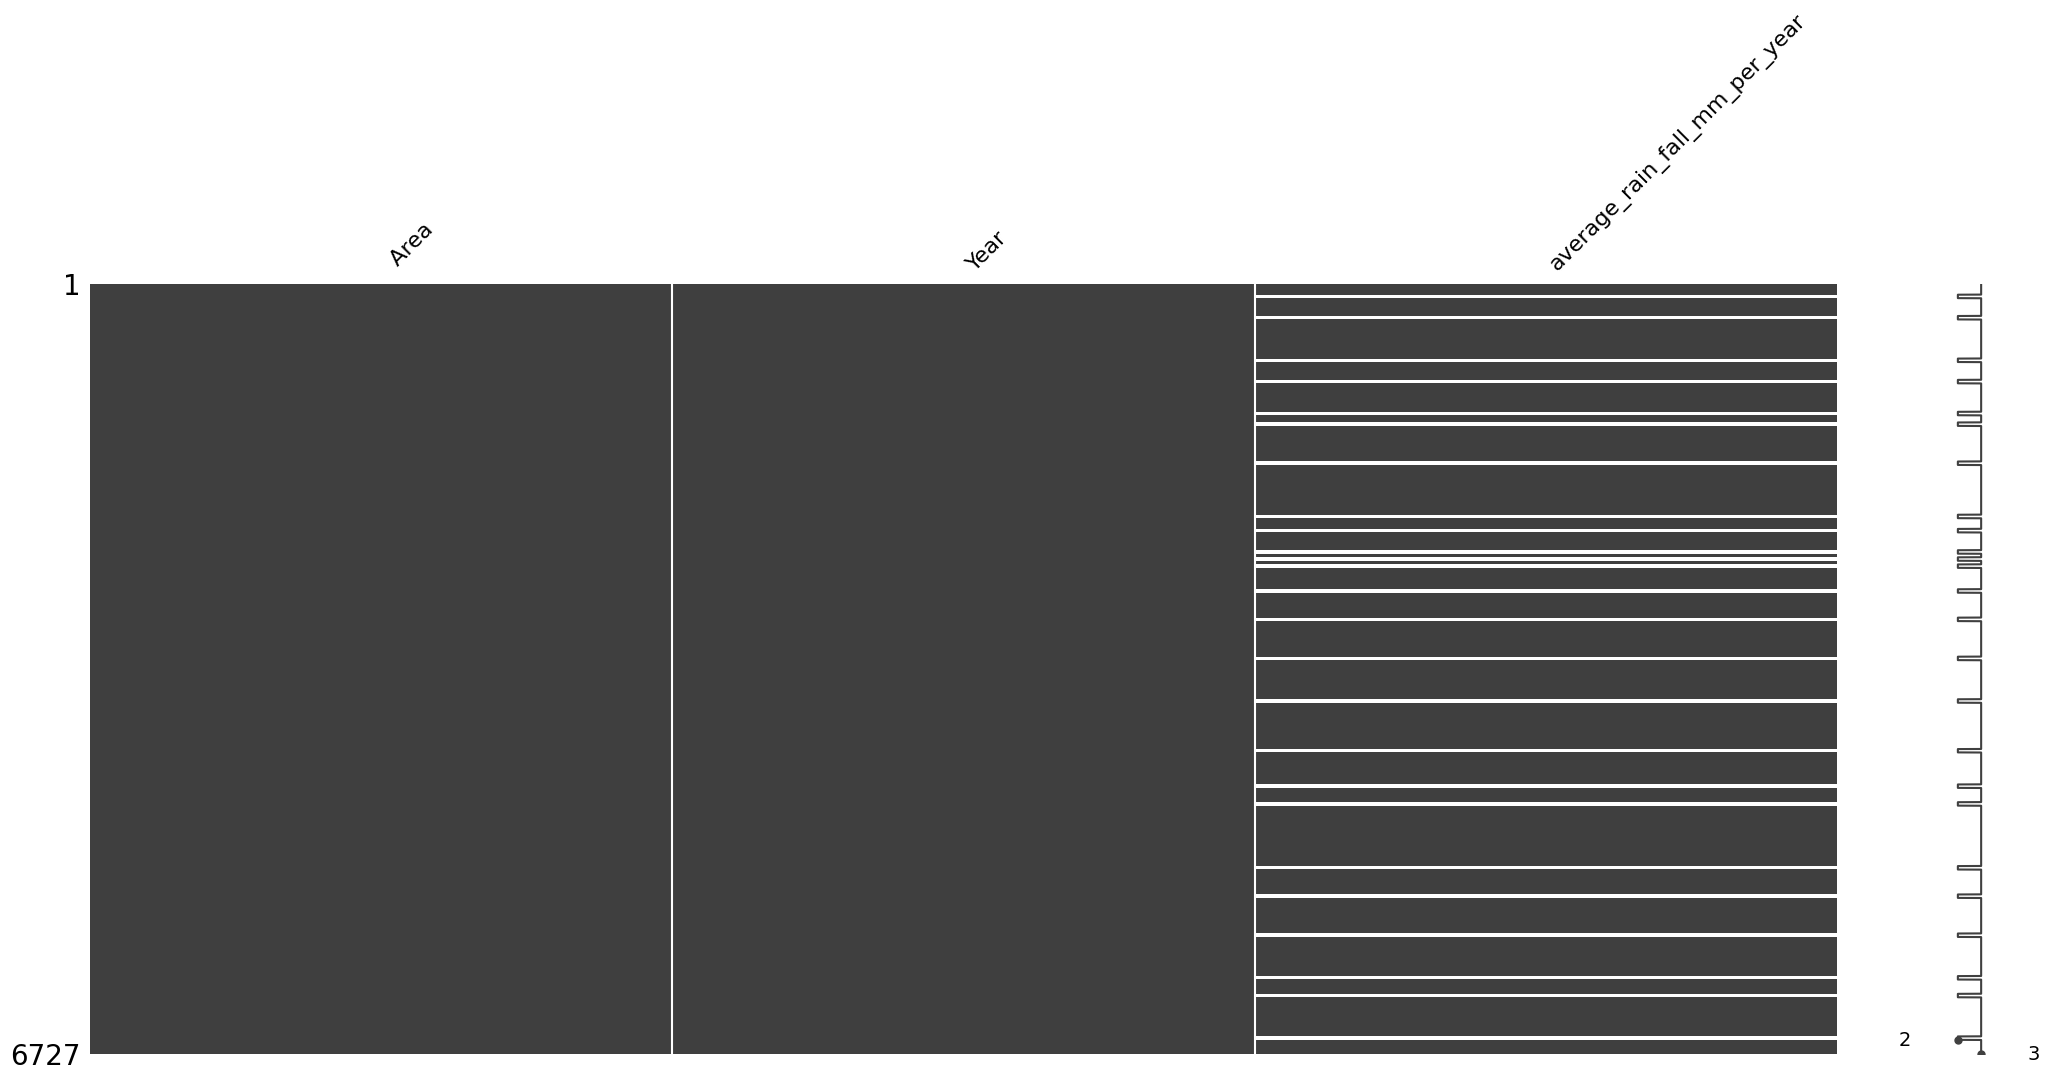

In [44]:
# Valeurs manquantes
print("Valeurs manquantes :")
print(df_rainfall.isnull().sum())
msno.matrix(df_rainfall)
plt.show()

**⚠️ 774 valeurs manquantes dans average_rain_fall_mm_per_year**

In [45]:
# Suppression des valeurs nulles
print(f"Shape avant suppression : {df_rainfall.shape}")
df_rainfall = df_rainfall.dropna()
print(f"Shape après suppression : {df_rainfall.shape}")

Shape avant suppression : (6727, 3)
Shape après suppression : (5953, 3)


### Nettoyage des colonnes 

In [46]:
# Corriger le nom de la colonne Area (espace en début)
print("Colonnes avant renommage :")
print(df_rainfall.columns.tolist())

df_rainfall.columns = df_rainfall.columns.str.strip()

print("\nColonnes après renommage :")
print(df_rainfall.columns.tolist())

Colonnes avant renommage :
[' Area', 'Year', 'average_rain_fall_mm_per_year']

Colonnes après renommage :
['Area', 'Year', 'average_rain_fall_mm_per_year']


### Nettoyage des valeurs et vérification des doublons

In [47]:
# Identifier les valeurs '..' (erreur de saisie)
valeurs_bizarres = df_rainfall[df_rainfall['average_rain_fall_mm_per_year'] == '..']
print(f"Nombre de lignes avec '..' : {len(valeurs_bizarres)}")
print("\nExemples :")
print(valeurs_bizarres)

Nombre de lignes avec '..' : 6

Exemples :
         Area  Year average_rain_fall_mm_per_year
403   Bahamas  1985                            ..
404   Bahamas  1986                            ..
406   Bahamas  1989                            ..
407   Bahamas  1990                            ..
408   Bahamas  1991                            ..
4061   Monaco  1985                            ..


In [48]:
# Suppression des lignes avec '..'
print(f"Shape avant suppression : {df_rainfall.shape}")
df_rainfall = df_rainfall[df_rainfall['average_rain_fall_mm_per_year'] != '..'].copy()
print(f"Shape après suppression : {df_rainfall.shape}")

Shape avant suppression : (5953, 3)
Shape après suppression : (5947, 3)


In [49]:
# Conversion en float
print(f"Type avant conversion : {df_rainfall['average_rain_fall_mm_per_year'].dtype}")
df_rainfall['average_rain_fall_mm_per_year'] = df_rainfall['average_rain_fall_mm_per_year'].astype(float)
print(f"Type après conversion : {df_rainfall['average_rain_fall_mm_per_year'].dtype}")

Type avant conversion : object
Type après conversion : float64


In [50]:
print(f"Shape avant consolidation : {df_rainfall.shape}")

# 1. Définition des clés d'unicité (Ce qui définit une ligne unique)
cols_cles = ['Area', 'Year']

# 2. Vérification du volume de doublons potentiels (sur les clés seulement)
doublons_cles = df_rainfall.duplicated(subset=cols_cles).sum()
print(f"🕵️‍♂️ Nombre d'entrées dupliquées sur les clés {cols_cles} : {doublons_cles}")

if doublons_cles > 0:
    # 3. Agrégation "Bculldozer" : On groupe par clé et on moyenne les valeurs numériques
    # Cela gère à la fois les doublons parfaits et les quasi-doublons
    df_rainfall = df_rainfall.groupby(cols_cles).mean().reset_index()
    
    print(f"✅ Consolidation effectuée par moyenne.")
    print(f"Shape après consolidation : {df_rainfall.shape}")
else:
    print("✅ Aucune consolidation nécessaire (les clés sont uniques).")

# Petit sanity check pour vérifier qu'on n'a pas perdu de colonnes
print("Colonnes restantes :", df_rainfall.columns.tolist())

Shape avant consolidation : (5947, 3)
🕵️‍♂️ Nombre d'entrées dupliquées sur les clés ['Area', 'Year'] : 0
✅ Aucune consolidation nécessaire (les clés sont uniques).
Colonnes restantes : ['Area', 'Year', 'average_rain_fall_mm_per_year']


### Analyse des outliers

In [51]:
df_rainfall['average_rain_fall_mm_per_year'].describe()

count    5947.000000
mean     1124.743232
std       786.257365
min        51.000000
25%       534.000000
50%      1010.000000
75%      1651.000000
max      3240.000000
Name: average_rain_fall_mm_per_year, dtype: float64

### Synthèse sur la Pluviométrie

**1. Nettoyage Technique :**
Les données brutes nécessitaient une conversion de type (String vers Float) et un nettoyage des valeurs manquantes non-standard (`..`).

**2. Intégrité et Physique :**
Contrairement aux autres datasets, celui-ci ne présentait **aucun doublon structurel**, confirmant la fiabilité de la source brute.
Les valeurs (de ~50mm pour les zones désertiques à >3000mm pour les zones tropicales) respectent les lois physiques.

**✅ Verdict :**
La variable `avg_rainfall` est validée. Bien qu'elle soit une moyenne annuelle (masquant la saisonnalité), elle constitue un proxy macro-climatique robuste pour la première phase de modélisation.

## Données sur les températures

**Source :** `temp.csv` - Températures moyennes annuelles

### Chargement et Vue d'ensemble

In [52]:
df_temp = pd.read_csv(DONNEES_AGRO_CLIMATIQUES / "temp.csv")
print(f"Shape : {df_temp.shape}")
df_temp.head()

Shape : (71311, 3)


,year,country,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67
3,1852,Côte D'Ivoire,NaN
4,1853,Côte D'Ivoire,NaN


In [53]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71311 entries, 0 to 71310
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      71311 non-null  int64  
 1   country   71311 non-null  object 
 2   avg_temp  68764 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.6+ MB


Valeurs manquantes :
year           0
country        0
avg_temp    2547
dtype: int64


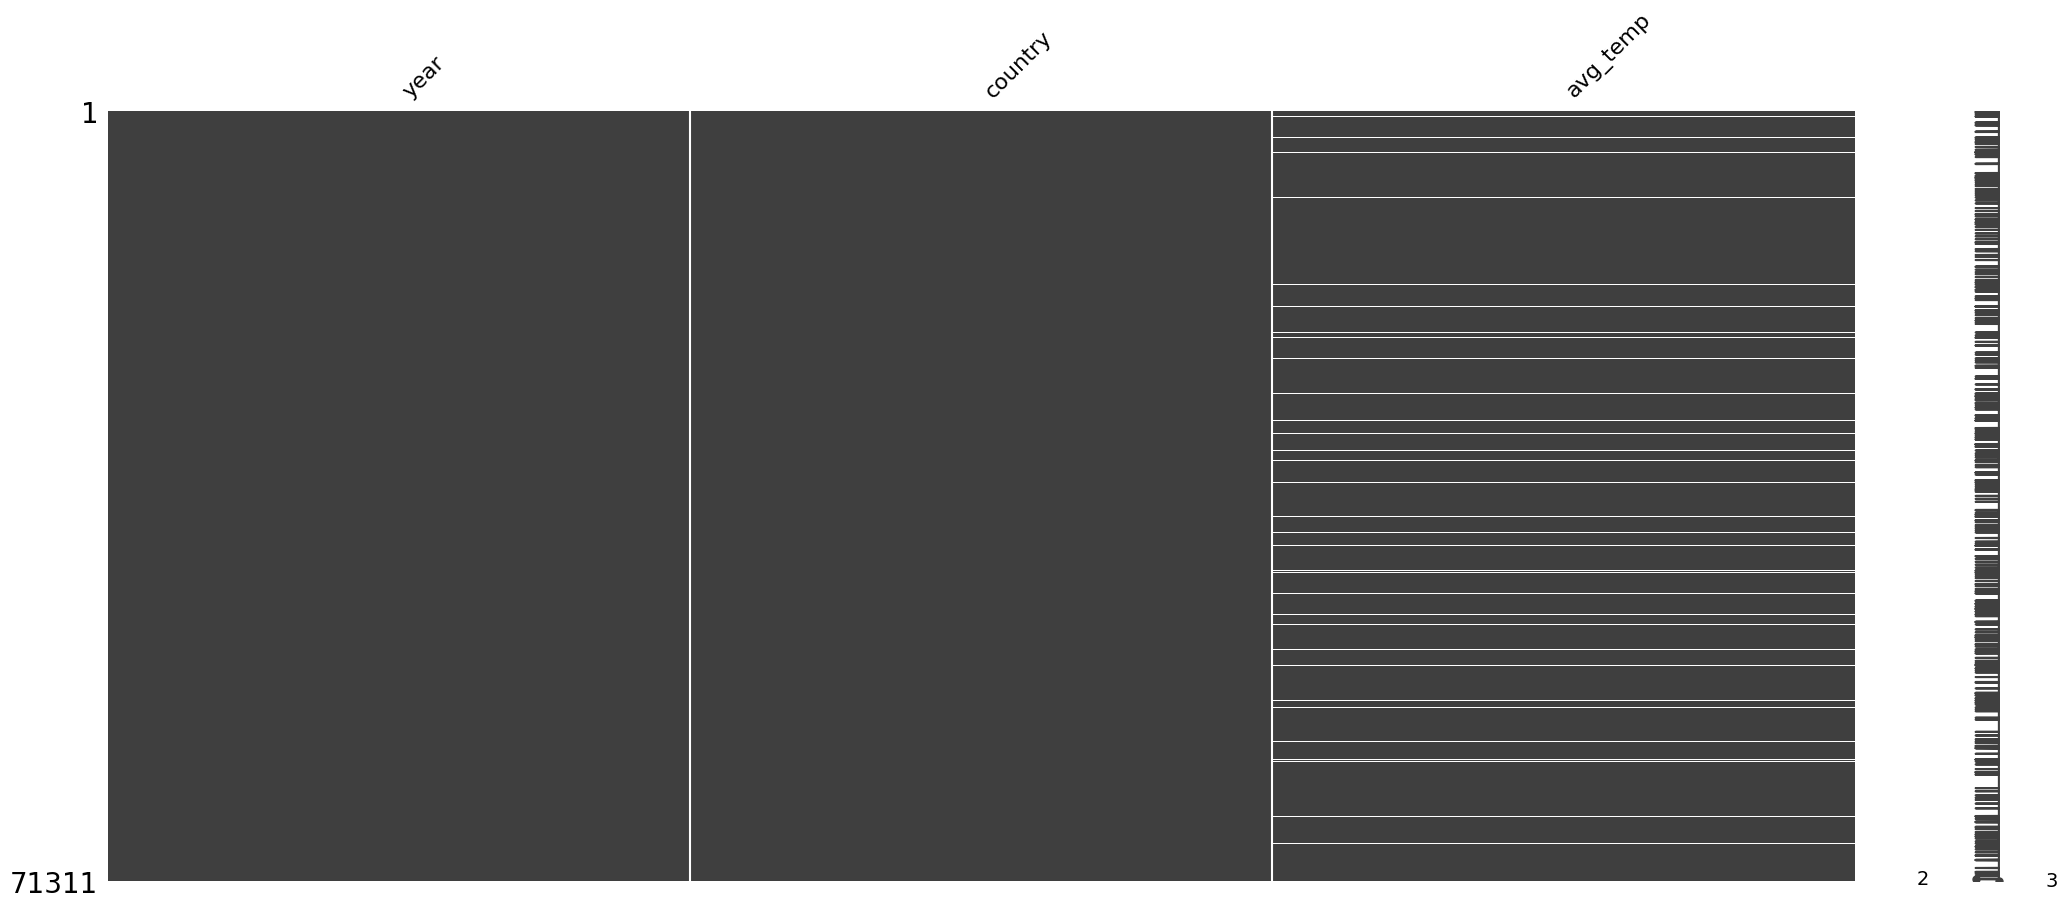

In [54]:
# Valeurs manquantes
print("Valeurs manquantes :")
print(df_temp.isnull().sum())
msno.matrix(df_temp)
plt.show()

**⚠️ 21,919 valeurs manquantes dans avg_temp (30.7%)**

In [55]:
# Suppression des valeurs nulles
print(f"Shape avant suppression : {df_temp.shape}")
df_temp = df_temp.dropna()
print(f"Shape après suppression : {df_temp.shape}")

Shape avant suppression : (71311, 3)
Shape après suppression : (68764, 3)


In [56]:
# Renommer pour cohérence avec autres datasets
df_temp.rename(columns={'year': 'Year', 'country': 'Area'}, inplace=True)
print("Colonnes après renommage :")
print(df_temp.columns.tolist())

Colonnes après renommage :
['Year', 'Area', 'avg_temp']


### Vérification des doublons

In [57]:
print(f"Shape avant consolidation : {df_temp.shape}")

# 1. Définition des clés d'unicité (Ce qui définit une ligne unique)
cols_cles = ['Year', 'Area']

# 2. Vérification du volume de doublons potentiels (sur les clés seulement)
doublons_cles = df_temp.duplicated(subset=cols_cles).sum()
print(f"🕵️‍♂️ Nombre d'entrées dupliquées sur les clés {cols_cles} : {doublons_cles}")

if doublons_cles > 0:
    # 3. Agrégation "Bculldozer" : On groupe par clé et on moyenne les valeurs numériques
    # Cela gère à la fois les doublons parfaits et les quasi-doublons
    df_temp = df_temp.groupby(cols_cles).mean().reset_index()
    
    print(f"✅ Consolidation effectuée par moyenne.")
    print(f"Shape après consolidation : {df_temp.shape}")
else:
    print("✅ Aucune consolidation nécessaire (les clés sont uniques).")

# Petit sanity check pour vérifier qu'on n'a pas perdu de colonnes
print("Colonnes restantes :", df_temp.columns.tolist())

Shape avant consolidation : (68764, 3)
🕵️‍♂️ Nombre d'entrées dupliquées sur les clés ['Year', 'Area'] : 41285
✅ Consolidation effectuée par moyenne.
Shape après consolidation : (27479, 3)
Colonnes restantes : ['Year', 'Area', 'avg_temp']


### Analyse des valeurs

In [58]:
df_temp.describe()

,Year,avg_temp
count,27479.000000,27479.000000
mean,1907.047891,16.231456
std,67.873286,7.953055
min,1743.000000,-12.130000
25%,1860.000000,9.080000
50%,1913.000000,16.250000
75%,1963.000000,24.490000
max,2013.000000,30.420000


In [59]:
# Vérification des pays à températures négatives
df_temp.sort_values(by=['avg_temp'], ascending=True).head(10)

,Year,Area,avg_temp
3151,1815,Kazakhstan,-12.130000
102,1745,Russia,-7.513333
99,1745,Norway,-5.970000
87,1745,Finland,-5.950000
3460,1820,Mongolia,-5.520000
4944,1841,Mongolia,-5.450000
4211,1831,Mongolia,-5.170000
5863,1851,Mongolia,-5.110000
6864,1860,Mongolia,-5.100000
8000,1870,Mongolia,-5.060000


In [60]:
# Vérification des pays à températures négatives
df_temp.groupby(by=['Area']).mean().sort_values(by=['avg_temp'], ascending=True).head(10)

,Year,avg_temp
Area,,
Mongolia,1916.500000,-3.367113
Norway,1879.955056,2.336105
Russia,1879.955056,2.725241
Kazakhstan,1912.500000,3.644282
Finland,1879.955056,4.244195
Estonia,1879.955056,4.883333
Latvia,1879.955056,5.232060
Belarus,1879.955056,5.360075
Lithuania,1879.955056,5.459139


### Conclusion sur les Températures

**1. Validité Météorologique :**
Les distributions sont cohérentes avec la climatologie réelle (ex: moyennes annuelles négatives ou faibles pour la Russie, le Canada ou la Mongolie). Les données ne sont pas corrompues.

**2. Biais Agronomique Identifié (Le "Piège de la Moyenne") :**
La moyenne annuelle masque la réalité physiologique des cultures.
* *Exemple :* Le blé pousse en Russie durant l'été (~15-20°C) et non à la température moyenne annuelle du pays (2.7°C).
* *Action à venir :* Ce biais sera corrigé dans le **Notebook 02** via une transformation climatique ciblant la **période de croissance** (cycle cultural) plutôt que l'année civile.

## Harmonisation des datasets pour la fusion
Pour garantir une fusion parfaite entre les datasets (Climat/Pesticides) et le dataset cible (Rendements), on réalise un audit des noms de pays.

### Identification des différences de syntaxe des pays

In [61]:
# 1. Définir le MAÎTRE (Yield)
# On prend les pays uniques du dataset de référence (qui contient la cible)
master_countries = df_rendements_fao['Area'].unique()

In [62]:
# Liste des autres dataframes à nettoyer
datasets_to_check = {
    "Climat": df_rendements_agro,
    "Pesticides": df_pesticides,
    "Rainfall": df_rainfall,
    "Temp": df_temp
}

Méthodologie : Utilisation de l'algorithme de distance de Levenshtein (thefuzz) pour identifier les quasi-homonymes.

In [63]:
# 2. La boucle d'Audit
print(f"⚙️ EXEMPLES LIMITES A 3 OCCURENCES POUR MONTRER LA METHODE")
for name, df in datasets_to_check.items():
    print(f"\n🕵️‍♂️ AUDIT DU DATASET : {name}")
    
    # Pays dans ce dataset
    current_countries = df['Area'].unique()
    
    # Ceux qui ne sont PAS dans le maître (Différence d'ensembles)
    missing = set(current_countries) - set(master_countries)
    
    print(f" -> {len(missing)} pays ne matchent pas exactement avec le dataset Maître.")
    
    if len(missing) > 0:
        print(" -> Tentative de résolution automatique (Top 5 exemples) :")
        
        # Petit algo de suggestion
        for pays_bizarre in list(missing)[:3]:
            # On cherche le meilleur match dans la liste maître
            match, score = process.extractOne(pays_bizarre, master_countries)
            
            if score >= 80: # Si ça ressemble à plus de 80%
                print(f"    Suggestion : '{pays_bizarre}'  ==>  '{match}' ? (Score: {score})")
            else:
                print(f"    Pas de match évident pour : '{pays_bizarre}'")

⚙️ EXEMPLES LIMITES A 3 OCCURENCES POUR MONTRER LA METHODE

🕵️‍♂️ AUDIT DU DATASET : Climat
 -> 0 pays ne matchent pas exactement avec le dataset Maître.

🕵️‍♂️ AUDIT DU DATASET : Pesticides
 -> 1 pays ne matchent pas exactement avec le dataset Maître.
 -> Tentative de résolution automatique (Top 5 exemples) :
    Suggestion : 'China, Macao SAR'  ==>  'China' ? (Score: 90)

🕵️‍♂️ AUDIT DU DATASET : Rainfall
 -> 31 pays ne matchent pas exactement avec le dataset Maître.
 -> Tentative de résolution automatique (Top 5 exemples) :
    Suggestion : 'Lao PDR'  ==>  'Ethiopia PDR' ? (Score: 86)
    Suggestion : 'Congo, Dem. Rep.'  ==>  'Congo' ? (Score: 90)
    Suggestion : 'Micronesia'  ==>  'Micronesia (Federated States of)' ? (Score: 90)

🕵️‍♂️ AUDIT DU DATASET : Temp
 -> 19 pays ne matchent pas exactement avec le dataset Maître.
 -> Tentative de résolution automatique (Top 5 exemples) :
    Suggestion : 'Taiwan'  ==>  'China, Taiwan Province of' ? (Score: 90)
    Suggestion : 'Czech Repub

### Consolidation Géopolitique

Certaines entités géographiques ont évolué (ex: scission Belgique/Luxembourg, ex-Soudan).
Pour garantir la continuité temporelle des séries, nous regroupons les anciennes entités avec les modernes dominantes.

In [64]:
# --- CORRECTION DES ENTITÉS HISTORIQUES (DANS LE DATASET MAÎTRE) ---

# Dictionnaire de consolidation historique
# On ramène les anciennes entités vers les entités modernes dominantes
historical_mapping = {
    'Belgium-Luxembourg': 'Belgium',  # Le Lux est négligeable vs Belgique en volume
    'Ethiopia PDR': 'Ethiopia',       # Ancienne république démocratique
    'Sudan (former)': 'Sudan'         # On assimile l'ancien Soudan au Nord (discutable mais pragmatique)
}

print("🛠️ Correction des entités géopolitiques historiques...")

# Vérification avant correction (pour le rapport)
for old, new in historical_mapping.items():
    n_old = df_rendements_fao[df_rendements_fao['Area'] == old].shape[0]
    if n_old > 0:
        print(f"   -> Fusion de '{old}' ({n_old} lignes) vers '{new}'.")

# Application de la correction
df_rendements_fao['Area'] = df_rendements_fao['Area'].replace(historical_mapping)

# IMPORTANT : Comme on a renommé, on risque d'avoir créé des doublons artificiels
# (Ex: Si 'Belgium' existait déjà en 1999 et 'Belgium-Luxembourg' aussi)
# On relance un petit coup de bulldozer par sécurité
cols_cles = ['Area', 'Item', 'Year']
rows_before = df_rendements_fao.shape[0]

df_rendements_fao = df_rendements_fao.groupby(cols_cles)['yield_hg_per_ha'].mean().reset_index()

rows_after = df_rendements_fao.shape[0]
if rows_before != rows_after:
    print(f"⚠️ Fusion effectuée : {rows_before - rows_after} doublons créés par le renommage ont été moyennés.")
else:
    print("✅ Aucun doublon créé par le renommage.")

🛠️ Correction des entités géopolitiques historiques...
   -> Fusion de 'Belgium-Luxembourg' (116 lignes) vers 'Belgium'.
   -> Fusion de 'Ethiopia PDR' (223 lignes) vers 'Ethiopia'.
   -> Fusion de 'Sudan (former)' (408 lignes) vers 'Sudan'.
✅ Aucun doublon créé par le renommage.


Validation : Vérification manuelle des suggestions pour éviter les faux positifs géopolitiques (ex: distinction stricte entre les deux Congo ou les deux Corées).

Résultat : Création d'un dictionnaire de mapping standardisé aligné sur le référentiel FAO. 👇🏼

In [65]:
# Création du Dictionnaire de Correction
# Clé = Nom "Sale" (dans Rainfall/Temp/Pest)
# Valeur = Nom "Propre" (dans Yield FAO Maître)

correction_map = {
    # --- Validés---
    'Macedonia': 'The former Yugoslav Republic of Macedonia',
    'Tanzania': 'United Republic of Tanzania',
    'St. Vincent and the Grenadines': 'Saint Vincent and the Grenadines',
    'Vietnam': 'Viet Nam',
    'Congo, Rep.': 'Congo', # Brazzaville
    'Moldova': 'Republic of Moldova',
    'Bolivia': 'Bolivia (Plurinational State of)',
    'Venezuela, RB': 'Venezuela (Bolivarian Republic of)',
    'United States': 'United States of America',
    'Micronesia': 'Micronesia (Federated States of)',
    'Syria': 'Syrian Arab Republic',
    'Iran': 'Iran (Islamic Republic of)',
    'Russia': 'Russian Federation',
    'North Korea': "Democratic People's Republic of Korea",
    'St. Kitts and Nevis': 'Saint Kitts and Nevis',
    'St. Lucia': 'Saint Lucia',
    "Cote d'Ivoire": "Côte d'Ivoire",
    "Côte D'Ivoire": "Côte d'Ivoire", # Casse différente
    'Congo (Democratic Republic Of The)': 'Democratic Republic of the Congo',
    'Taiwan': 'China, Taiwan Province of',
    'Guinea Bissau': 'Guinea-Bissau',
    'Bosnia And Herzegovina': 'Bosnia and Herzegovina',
    'Hong Kong': 'China, Hong Kong SAR',
    'Venezuela': 'Venezuela (Bolivarian Republic of)',
    
    # Correction du Congo (Kinshasa)
    'Congo, Dem. Rep.': 'Democratic Republic of the Congo', 
    
    # Cas de la Corée du Sud (sinon perdue)
    'South Korea': 'Republic of Korea',
    'South Korea ': 'Republic of Korea',
    
    # Laos
    'Laos': "Lao People's Democratic Republic",
    'Lao PDR': "Lao People's Democratic Republic",

    # Pays de l'Europe de l'est + Kyrgyzstan
    'Czech Republic': 'Czechia',
    'Slovak Republic': 'Slovakia',
    'Kyrgyz Republic': 'Kyrgyzstan',
}

print("✅ Dictionnaire de mapping chargé.")

# Application du Mapping sur les datasets annexes
# On utilise .replace() qui est très efficace pour ça

datasets_to_fix = [df_rainfall, df_temp, df_pesticides]
names_datasets = ["Pluviométrie", "Températures", "Pesticides"]

for df, name in zip(datasets_to_fix, names_datasets):
    # On remplace les valeurs dans la colonne Area
    # Si la clé n'existe pas, il ne touche à rien (c'est safe)
    df['Area'] = df['Area'].replace(correction_map)
    print(f"🔄 Corrections appliquées sur : {name}")

# Contrôle post-correction pour la Corée du Sud
print("\n--- Vérification Corée du Sud ---")
for df, name in zip(datasets_to_fix, names_datasets):
    if 'Republic of Korea' in df['Area'].values:
        print(f"✅ 'Republic of Korea' présent dans {name}")
    else:
        print(f"⚠️ 'Republic of Korea' ABSENT dans {name}")

✅ Dictionnaire de mapping chargé.
🔄 Corrections appliquées sur : Pluviométrie
🔄 Corrections appliquées sur : Températures
🔄 Corrections appliquées sur : Pesticides

--- Vérification Corée du Sud ---
✅ 'Republic of Korea' présent dans Pluviométrie
✅ 'Republic of Korea' présent dans Températures
✅ 'Republic of Korea' présent dans Pesticides


In [66]:
# Analyse du chevauchement temporel
# Identifier la période commune optimale
years_fao = set(df_rendements_fao['Year'].unique())
years_agro = set(df_rendements_agro['Year'].unique())
years_pesticides = set(df_pesticides['Year'].unique())
years_rainfall = set(df_rainfall['Year'].unique())
years_temp = set(df_temp['Year'].unique())

In [67]:
# Intersection complète (tous les datasets)
years_all = years_fao & years_agro & years_pesticides & years_rainfall & years_temp

In [68]:
annees_triees = sorted(years_all)

In [69]:
print(f"Années communes : {annees_triees}")

Années communes : [np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013)]


In [70]:
print(years_all)

{np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013)}


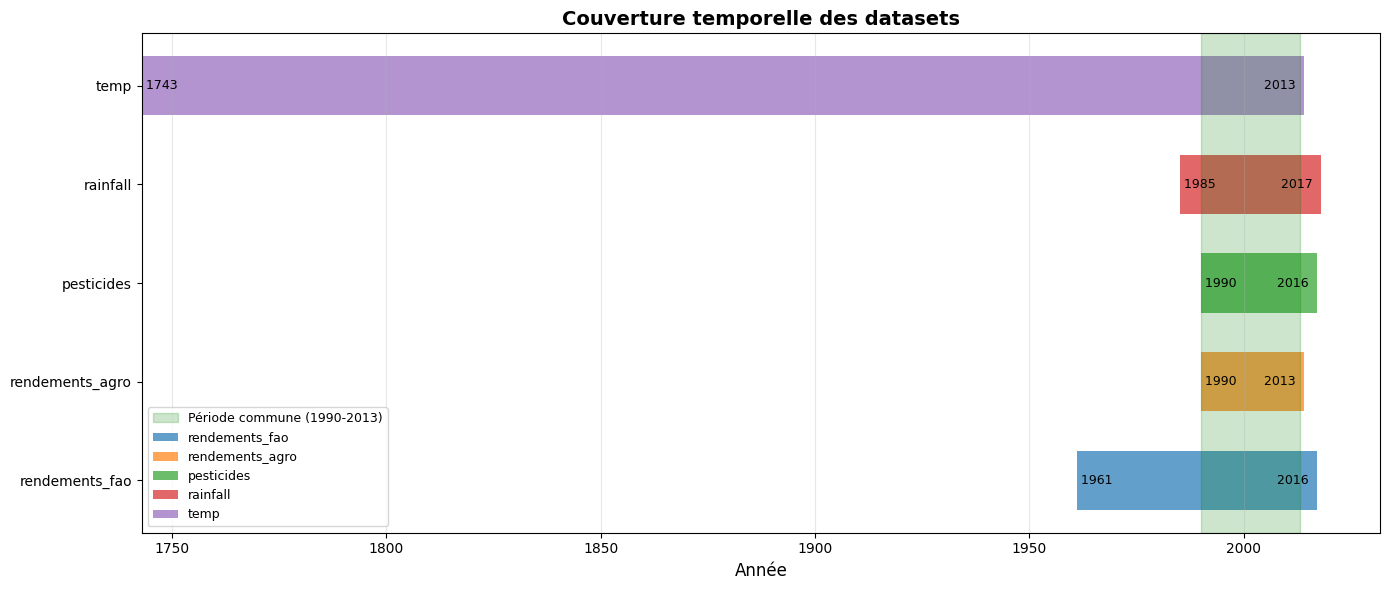

In [71]:
# Visualisation
fig, ax = plt.subplots(figsize=(14, 6))

datasets_timeline = [
    ("rendements_fao", min(years_fao), max(years_fao)),
    ("rendements_agro", min(years_agro), max(years_agro)),
    ("pesticides", min(years_pesticides), max(years_pesticides)),
    ("rainfall", min(years_rainfall), max(years_rainfall)),
    ("temp", min(years_temp), max(years_temp))
]

for i, (name, start, end) in enumerate(datasets_timeline):
    ax.barh(i, end - start + 1, left=start, height=0.6, 
            label=name, alpha=0.7)
    ax.text(start, i, f" {start}", va='center', fontsize=9)
    ax.text(end, i, f"{end} ", va='center', ha='right', fontsize=9)

# Zone commune
if years_all:
    ax.axvspan(min(years_all), max(years_all), alpha=0.2, color='green', 
               label=f'Période commune ({min(years_all)}-{max(years_all)})')

ax.set_yticks(range(len(datasets_timeline)))
ax.set_yticklabels([name for name, _, _ in datasets_timeline])
ax.set_xlabel('Année', fontsize=12)
ax.set_title('Couverture temporelle des datasets', fontsize=14, fontweight='bold')

ax.legend(loc='lower left', fontsize=9)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Concordance des cultures datasets rendements

In [72]:
print("\n✅ Vérification Item (cultures) :")
for name, df in [
    ("df_rendements_fao", df_rendements_fao),
    ("df_rendements_agro", df_rendements_agro)
]:
    has_item = 'Item' in df.columns
    unique_items = df['Item'].nunique() if has_item else "N/A"
    print(f"  ✅ {name:25} → Item présent : {has_item}, cultures uniques : {unique_items}")


✅ Vérification Item (cultures) :
  ✅ df_rendements_fao         → Item présent : True, cultures uniques : 10
  ✅ df_rendements_agro        → Item présent : True, cultures uniques : 10


📊 Rainfall : Diff Moyenne = 0.00 mm | Corr = 1.0000
📊 Temperature : Diff Moyenne = 0.00 °C | Corr = 1.0000
📊 Pesticides : Diff Moyenne = 0.00 tonnes | Corr = 1.0000


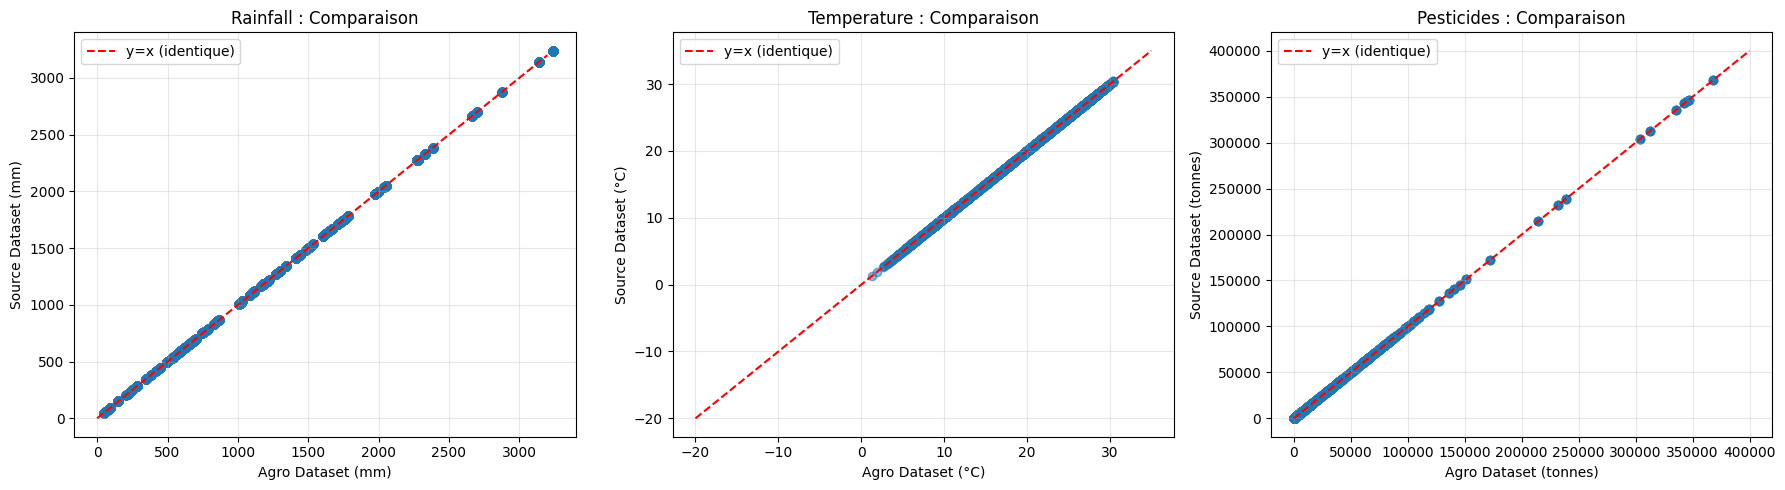

In [73]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Configuration : On définit les paramètres qui changent pour chaque dataset
comparisons = [
    {
        "name": "Rainfall",
        "df_source": df_rainfall,
        "col": "average_rain_fall_mm_per_year",
        "unit": "mm",
        "suffix": "_rainfall",
        "limit": [0, 3200] # Limites pour le graph
    },
    {
        "name": "Temperature",
        "df_source": df_temp,
        "col": "avg_temp",
        "unit": "°C",
        "suffix": "_temp",
        "limit": [-20, 35]
    },
    {
        "name": "Pesticides",
        "df_source": df_pesticides,
        "col": "pesticides_tonnes",
        "unit": "tonnes",
        "suffix": "_pest",
        "limit": [0, 400000]
    }
]

# 2. Création de la figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3. La Boucle Magique
for i, config in enumerate(comparisons):
    col = config['col']
    df_source = config['df_source']
    ax = axes[i]
    
    # A. Le Merge (Fusion)
    merged = df_rendements_agro[['Area', 'Year', col]].merge(
        df_source[['Area', 'Year', col]],
        on=['Area', 'Year'],
        how='inner',
        suffixes=('_agro', '_source')
    )
    
    # B. Calcul des stats
    diff = (merged[f'{col}_agro'] - merged[f'{col}_source']).abs()
    correlation = merged[f'{col}_agro'].corr(merged[f'{col}_source'])
    
    print(f"📊 {config['name']} : Diff Moyenne = {diff.mean():.2f} {config['unit']} | Corr = {correlation:.4f}")
    
    # C. Le Plotting (Graphique)
    ax.scatter(merged[f'{col}_agro'], merged[f'{col}_source'], alpha=0.3)
    
    # Ligne d'identité y=x
    ax.plot(config['limit'], config['limit'], 'r--', label='y=x (identique)')
    
    # Cosmétique
    ax.set_title(f"{config['name']} : Comparaison")
    ax.set_xlabel(f"Agro Dataset ({config['unit']})")
    ax.set_ylabel(f"Source Dataset ({config['unit']})")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## Fusion des datasets FAO et _agro

In [74]:
# 1. APPLICATION DU FILTRE TEMPOREL (1990-2013)
# On applique le filtre sur le dataset MAÎTRE (FAO) avant toute chose
df_fao_filtered = df_rendements_fao[
    (df_rendements_fao['Year'] >= 1990) & 
    (df_rendements_fao['Year'] <= 2013)
].copy()

print(f"📉 Bornage 1990-2013 appliqué sur FAO. Lignes restantes : {len(df_fao_filtered)}")


# 2. PRÉPARATION DES FEATURES (Dataset Agro)
# Attention : Dans df_rendements_agro, il y a plusieurs lignes par pays/année (une par culture).
# Mais la météo est la même pour toutes les cultures d'un pays donné une année donnée.
# Il faut donc isoler les features UNIQUES pour éviter d'exploser le nombre de lignes à la fusion.

cols_features = [
    'Area', 
    'Year', 
    'average_rain_fall_mm_per_year', 
    'pesticides_tonnes', 
    'avg_temp' 
]

# On ne garde que les couples (Pays, Année) uniques pour la météo
df_features_unique = df_rendements_agro[cols_features].drop_duplicates(subset=['Area', 'Year'])

print(f"🌤️ Features climatiques uniques extraites : {len(df_features_unique)} lignes")


# 3. LA FUSION (INNER JOIN)
# On fusionne le FAO borné avec la Météo.
# 'inner' va garder uniquement les lignes où on a TOUT (Rendement + Météo + Pesticides)
# Les années hors 1990-2013 du fichier Agro seront naturellement ignorées.

df_fao_consolidated = df_fao_filtered.merge(
    df_features_unique,
    on=['Area', 'Year'],
    how='inner'
)

# 4. VERIFICATIONS FINALES
print(f"\nDATASET FINAL CRÉÉ")
print(f"Dimensions : {df_fao_consolidated.shape}")
print(f"Période couverte : {df_fao_consolidated['Year'].min()} - {df_fao_consolidated['Year'].max()}")
print("-" * 30)

# Check s'il y a des trous (NaN)
missing = df_fao_consolidated.isnull().sum().sum()
if missing == 0:
    print("✨ Intégrité parfaite : 0 valeurs manquantes.")
else:
    print(f"⚠️ Attention : {missing} valeurs manquantes détectées (à vérifier).")

# Aperçu
df_fao_consolidated.head()

📉 Bornage 1990-2013 appliqué sur FAO. Lignes restantes : 25766
🌤️ Features climatiques uniques extraites : 2250 lignes

DATASET FINAL CRÉÉ
Dimensions : (13030, 7)
Période couverte : 1990 - 2013
------------------------------
✨ Intégrité parfaite : 0 valeurs manquantes.


,Area,Item,Year,yield_hg_per_ha,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613.0,1485.0,121.0,16.37
1,Albania,Maize,1991,29068.0,1485.0,121.0,15.36
2,Albania,Maize,1992,24876.0,1485.0,121.0,16.06
3,Albania,Maize,1993,24185.0,1485.0,121.0,16.05
4,Albania,Maize,1994,25848.0,1485.0,201.0,16.96


# Préparation dataset Crop Yield

## EDA

### Chargement et vue d'ensemble

In [75]:
# Chargement dataset
df_cropyields = pd.read_csv(DONNEES_HISTORIQUES / "crop_yield.csv")

print(f"Shape : {df_cropyields.shape}")
df_cropyields.head()

Shape : (1000000, 10)


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [76]:
# Vérification des doublons
doublons_histo = df_cropyields.duplicated().sum()
print(f"🕵️‍♂️ Doublons détectés : {doublons_histo}")

if doublons > 0:
    # Suppression
    df_cropyields = df_cropyields.drop_duplicates()
    print(f"✅ Doublons supprimés. Nouvelle shape : {df_cropyields.shape}")
else:
    print("✅ Aucun doublon détecté.")

🕵️‍♂️ Doublons détectés : 0
✅ Aucun doublon détecté.


In [77]:
# Informations générales
df_cropyields.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  object 
 1   Soil_Type               1000000 non-null  object 
 2   Crop                    1000000 non-null  object 
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  object 
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), object(4)
memory usage: 62.9+ MB


<Axes: >

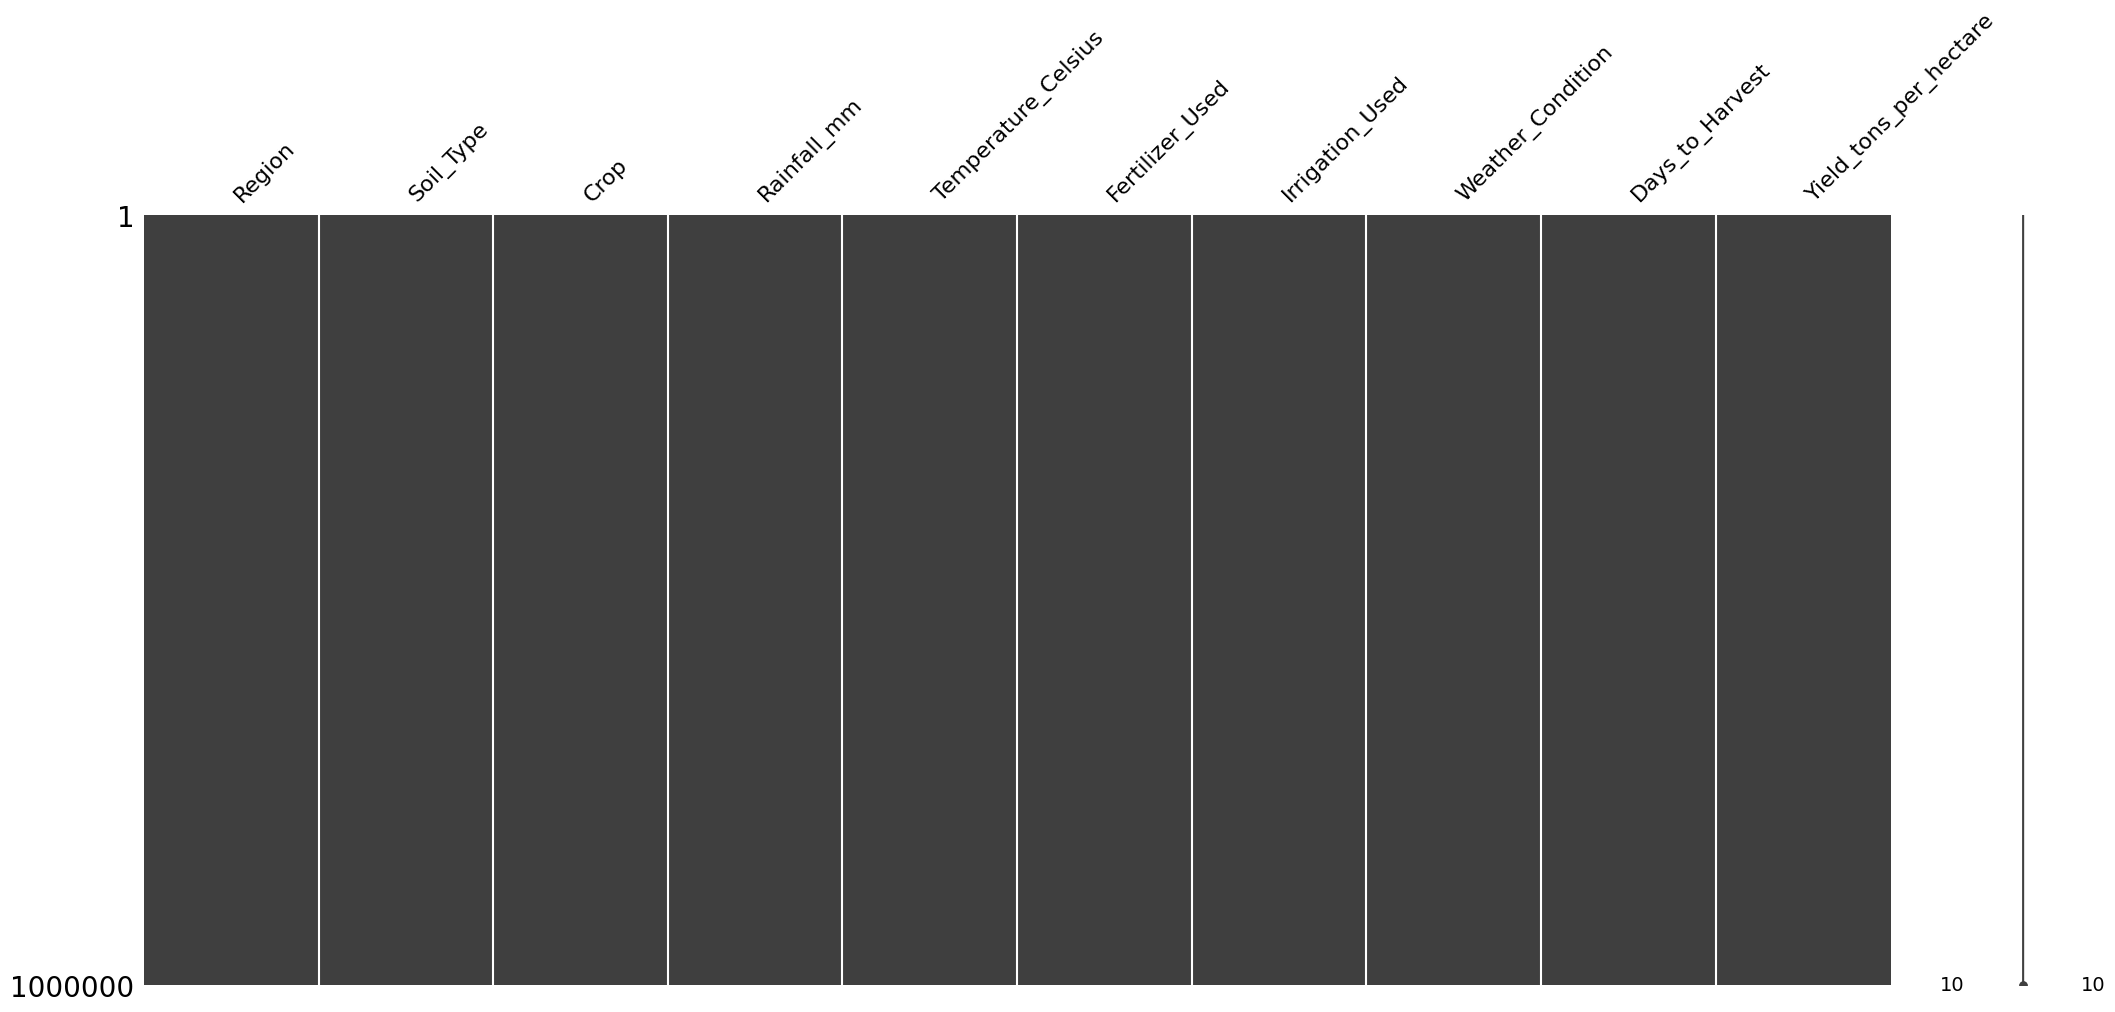

In [78]:
msno.matrix(df_cropyields)

Le graphe Missingno ne montre aucune valeur manquante

### Statistiques descriptives

In [79]:
df_cropyields.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


On observe des rendements négatifs, on va les supprimer

In [80]:
print(f"Shape avant : {df_cropyields.shape}")
df_cropyields = df_cropyields.drop(df_cropyields[df_cropyields['Yield_tons_per_hectare'] < 0].index)
print(f"Shape après : {df_cropyields.shape}")

Shape avant : (1000000, 10)
Shape après : (999769, 10)


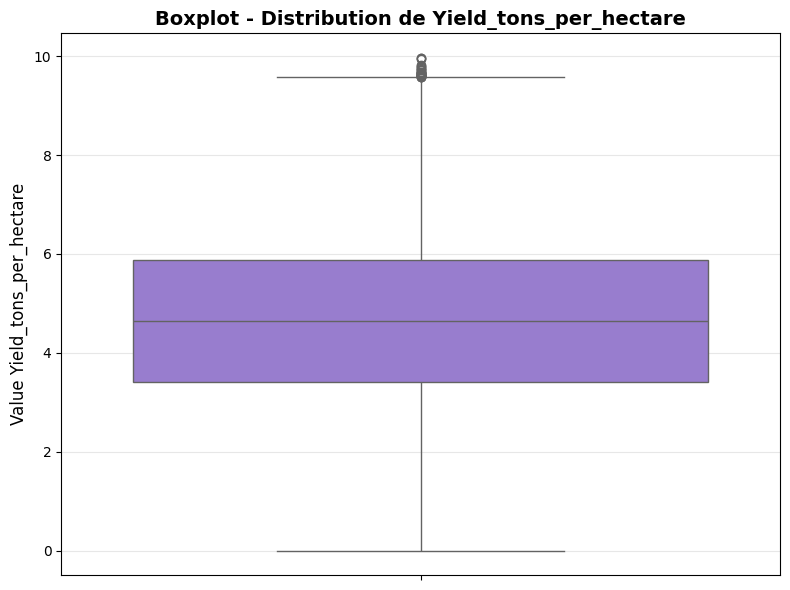


ANALYSE DES OUTLIERS
Q1 (25%) : 3.42
Q3 (75%) : 5.88
IQR : 2.46
Limite basse outliers : -0.27
Limite haute outliers : 9.57
Nombre d'outliers : 28 (0.00%)


In [81]:
# Créer le boxplot vertical
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_cropyields['Yield_tons_per_hectare'], color='mediumpurple')
plt.ylabel('Value Yield_tons_per_hectare', fontsize=12)
plt.title('Boxplot - Distribution de Yield_tons_per_hectare', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Statistiques sur les outliers
Q1 = df_cropyields['Yield_tons_per_hectare'].quantile(0.25)
Q3 = df_cropyields['Yield_tons_per_hectare'].quantile(0.75)
IQR = Q3 - Q1
outlier_low = Q1 - 1.5 * IQR
outlier_high = Q3 + 1.5 * IQR

nb_outliers = ((df_cropyields['Yield_tons_per_hectare'] < outlier_low) | 
               (df_cropyields['Yield_tons_per_hectare'] > outlier_high)).sum()

print(f"\n{'='*50}")
print(f"ANALYSE DES OUTLIERS")
print(f"{'='*50}")
print(f"Q1 (25%) : {Q1:.2f}")
print(f"Q3 (75%) : {Q3:.2f}")
print(f"IQR : {IQR:.2f}")
print(f"Limite basse outliers : {outlier_low:.2f}")
print(f"Limite haute outliers : {outlier_high:.2f}")
print(f"Nombre d'outliers : {nb_outliers} ({nb_outliers/len(df_cropyields)*100:.2f}%)")

In [82]:
# Distribution variables catégorielles
print("=== DISTRIBUTION VARIABLES CATÉGORIELLES ===\n")

print("Crop (Culture) :")
print(df_cropyields['Crop'].value_counts())
print(f"\nNombre de cultures : {df_cropyields['Crop'].nunique()}")

print("\nSoil_Type (Type de sol) :")
print(df_cropyields['Soil_Type'].value_counts())
print(f"\nNombre de types de sol : {df_cropyields['Soil_Type'].nunique()}")

print("\nRegion :")
print(df_cropyields['Region'].value_counts())

print("\n📊 Distribution quasi-uniforme sur toutes les variables catégorielles")

=== DISTRIBUTION VARIABLES CATÉGORIELLES ===

Crop (Culture) :
Crop
Maize      166785
Rice       166754
Barley     166727
Wheat      166640
Cotton     166548
Soybean    166315
Name: count, dtype: int64

Nombre de cultures : 6

Soil_Type (Type de sol) :
Soil_Type
Sandy     167081
Loam      166757
Chalky    166735
Silt      166633
Clay      166311
Peaty     166252
Name: count, dtype: int64

Nombre de types de sol : 6

Region :
Region
North    250112
West     250014
South    250001
East     249642
Name: count, dtype: int64

📊 Distribution quasi-uniforme sur toutes les variables catégorielles


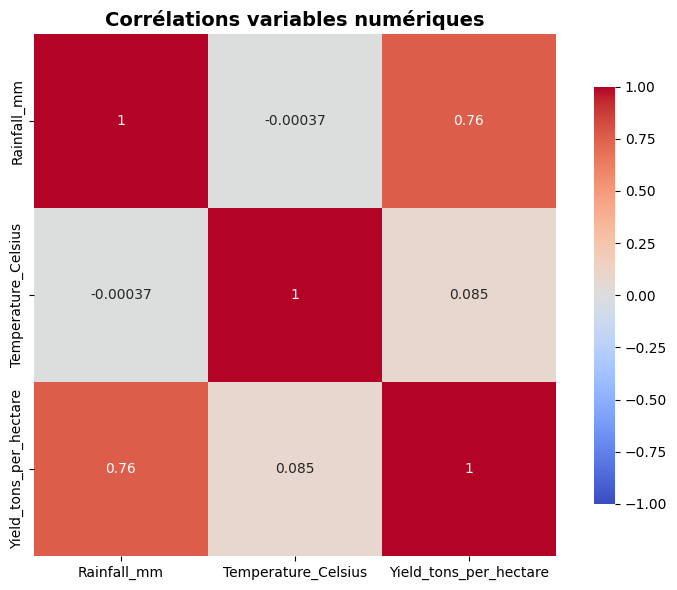


📈 Rainfall → Yield : 0.765 (FORTE)
📈 Temperature → Yield : 0.085 (faible)


In [83]:
# Corrélation variables numériques
num_vars = ['Rainfall_mm', 'Temperature_Celsius', 'Yield_tons_per_hectare']
correlations = df_cropyields[num_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlations, annot=True, cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8})
plt.title('Corrélations variables numériques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📈 Rainfall → Yield : {correlations.loc['Rainfall_mm', 'Yield_tons_per_hectare']:.3f} (FORTE)")
print(f"📈 Temperature → Yield : {correlations.loc['Temperature_Celsius', 'Yield_tons_per_hectare']:.3f} (faible)")

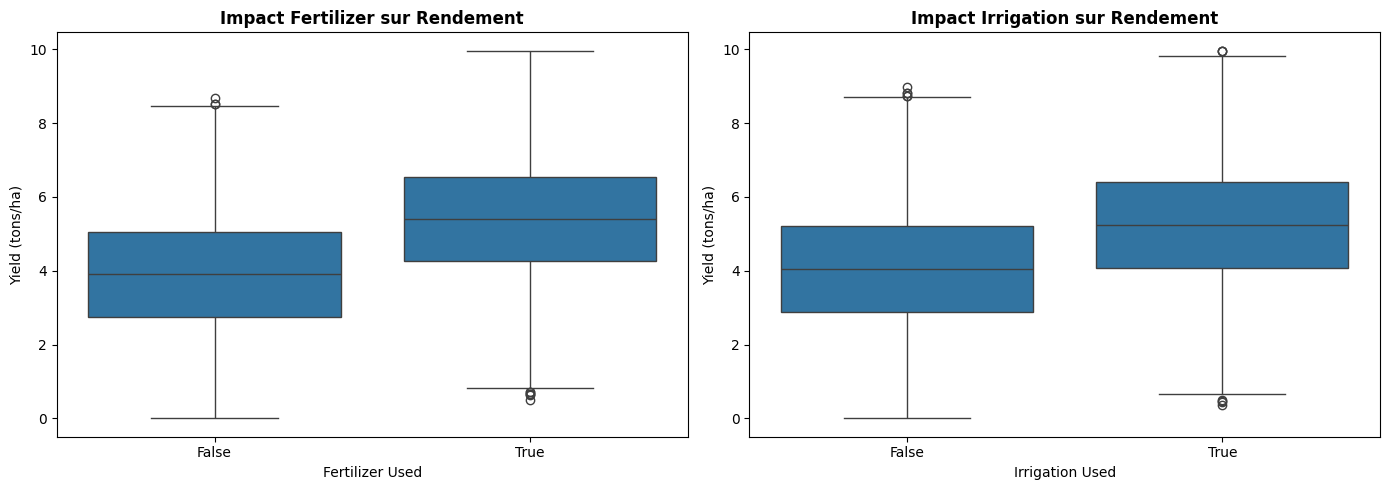

✅ Impact MAJEUR de Fertilizer et Irrigation sur rendements (+40-50%)


In [84]:
# Impact Fertilizer & Irrigation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fertilizer
sns.boxplot(data=df_cropyields, x='Fertilizer_Used', y='Yield_tons_per_hectare', ax=axes[0])
axes[0].set_title('Impact Fertilizer sur Rendement', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fertilizer Used')
axes[0].set_ylabel('Yield (tons/ha)')

# Irrigation
sns.boxplot(data=df_cropyields, x='Irrigation_Used', y='Yield_tons_per_hectare', ax=axes[1])
axes[1].set_title('Impact Irrigation sur Rendement', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Irrigation Used')
axes[1].set_ylabel('Yield (tons/ha)')

plt.tight_layout()
plt.show()

print("✅ Impact MAJEUR de Fertilizer et Irrigation sur rendements (+40-50%)")

### Preuve structure catalogue

In [85]:
# Calcul combinaisons uniques
print("=== ANALYSE STRUCTURE CATALOGUE ===\n")

# Combinaisons Crop × Soil × Fertilizer × Irrigation
n_combinations = df_cropyields.groupby([
    'Crop', 'Soil_Type', 'Fertilizer_Used', 'Irrigation_Used'
]).size()

print(f"Combinaisons observées : {len(n_combinations)}")

# Combinaisons théoriques
n_crops = df_cropyields['Crop'].nunique()
n_soils = df_cropyields['Soil_Type'].nunique()
n_fert = 2  # True/False
n_irrig = 2  # True/False

max_combinations = n_crops * n_soils * n_fert * n_irrig
print(f"Combinaisons théoriques : {max_combinations} ({n_crops} crops × {n_soils} sols × 2 fert × 2 irrig)")
print(f"Couverture : {len(n_combinations)/max_combinations*100:.1f}%")

print(f"\nDistribution observations par combinaison :")
print(f"  Moyenne : {n_combinations.mean():.0f}")
print(f"  Écart-type : {n_combinations.std():.0f}")
print(f"  Min : {n_combinations.min()}")
print(f"  Max : {n_combinations.max()}")

print("\n✅ CONCLUSION : Grille combinatoire EXHAUSTIVE avec distribution quasi-uniforme")
print("   → Dataset = CATALOGUE SYNTHÉTIQUE, pas observations réelles")

=== ANALYSE STRUCTURE CATALOGUE ===

Combinaisons observées : 144
Combinaisons théoriques : 144 (6 crops × 6 sols × 2 fert × 2 irrig)
Couverture : 100.0%

Distribution observations par combinaison :
  Moyenne : 6943
  Écart-type : 82
  Min : 6738
  Max : 7139

✅ CONCLUSION : Grille combinatoire EXHAUSTIVE avec distribution quasi-uniforme
   → Dataset = CATALOGUE SYNTHÉTIQUE, pas observations réelles


A titre d'exemple : on va tester la combinaison Wheat + Clay + Fert + Irrig et observer graphiquement la répartition des valeurs de pluviométries et de températures :

C:\Users\Fab\AppData\Local\Temp\ipykernel_11828\2934207492.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


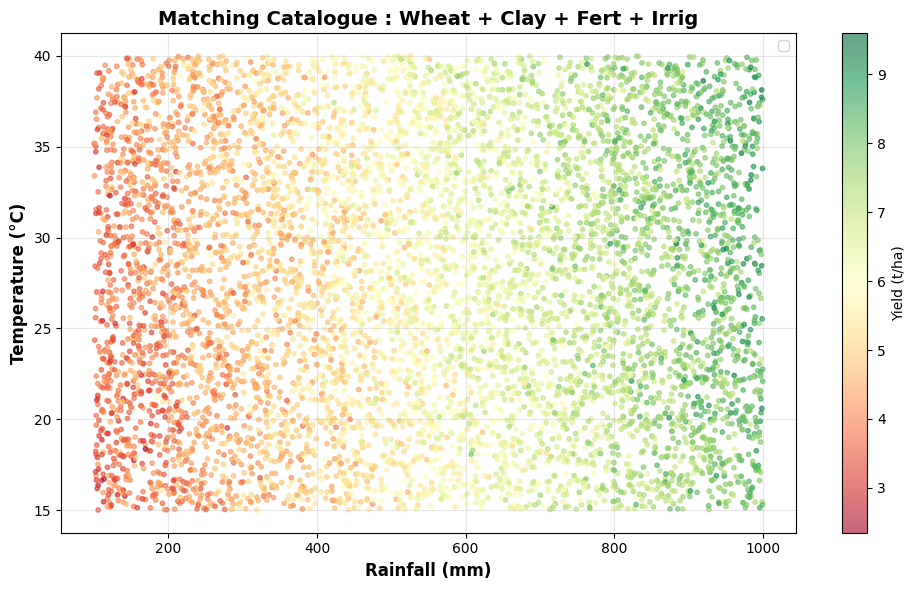

In [86]:
# Sélection 1 combinaison exemple
combo_example = df_cropyields[
    (df_cropyields['Crop'] == 'Wheat') &
    (df_cropyields['Soil_Type'] == 'Clay') &
    (df_cropyields['Fertilizer_Used'] == True) &
    (df_cropyields['Irrigation_Used'] == True)
]

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Scatter 2D coloré par Yield
scatter = ax.scatter(
    combo_example['Rainfall_mm'], 
    combo_example['Temperature_Celsius'],
    c=combo_example['Yield_tons_per_hectare'],
    cmap='RdYlGn', alpha=0.6, s=10
)

ax.set_xlabel('Rainfall (mm)', fontsize=12, fontweight='bold')
ax.set_ylabel('Temperature (°C)', fontsize=12, fontweight='bold')
ax.set_title('Matching Catalogue : Wheat + Clay + Fert + Irrig', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.colorbar(scatter, ax=ax, label='Yield (t/ha)')
plt.tight_layout()
plt.show()



Ici, de façon visuelle, on observe bien une répartition uniforme des Rainfall et Temperature sur l'exemple de combinaison

**💡 Observation Agronomique Critique (Saisonnalité) :**
>
> Nous observons que la température minimale du dataset est de **15°C**.
> Dans un contexte agricole tempéré (blé, orge), une **moyenne annuelle** de 15°C serait très élevée.
>
> **Interprétation :** Les températures de ce simulateur ne correspondent pas à des moyennes annuelles (lissées par l'hiver), mais bien aux températures moyennes durant la **Période de Culture active (Growing Season Temperature)**.
> C'est cohérent avec l'objectif du simulateur : modéliser les conditions directes de croissance de la plante.


### Validation rapide de la cohérence agronomique
On va tester une régression linéaire rapide (50k obsercations) sur le dataset pour valider sa cohérence agronomique.

In [87]:
print("=== VALIDATION RAPIDE COHÉRENCE AGRONOMIQUE ===\n")

start = time.time()

# Échantillon 50k lignes (rapide)
df_sample = df_cropyields.sample(50000, random_state=RANDOM_STATE).copy()

# Encodage simple
df_sample['Soil_encoded'] = df_sample['Soil_Type'].astype('category').cat.codes
df_sample['Fert_int'] = df_sample['Fertilizer_Used'].astype(int)
df_sample['Irrig_int'] = df_sample['Irrigation_Used'].astype(int)

# Features → Target
X = df_sample[['Rainfall_mm', 'Temperature_Celsius', 'Soil_encoded', 'Fert_int', 'Irrig_int']]
y = df_sample['Yield_tons_per_hectare']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# Régression linéaire (ultra-rapide)
model = LinearRegression()
model.fit(X_train, y_train)
r2 = r2_score(y_test, model.predict(X_test))

elapsed = time.time() - start

print(f"✅ R² = {r2:.3f} (Régression Linéaire sur 50k obs)")
print(f"⏱️  Temps calcul : {elapsed:.1f}s")
print(f"\n📊 Interprétation :")
if r2 > 0.85:
    print("   → Relations agronomiques TRÈS COHÉRENTES (R²>0.85)")
    print("   → Catalogue FIABLE pour personnalisation rendements")
elif r2 > 0.70:
    print("   → Relations agronomiques COHÉRENTES (R²>0.70)")
    print("   → Catalogue utilisable pour ajustements")
else:
    print("   ⚠️  Cohérence limitée, vérifications supplémentaires nécessaires")

=== VALIDATION RAPIDE COHÉRENCE AGRONOMIQUE ===

✅ R² = 0.914 (Régression Linéaire sur 50k obs)
⏱️  Temps calcul : 0.1s

📊 Interprétation :
   → Relations agronomiques TRÈS COHÉRENTES (R²>0.85)
   → Catalogue FIABLE pour personnalisation rendements


Le modèle est performant ($R^2 > 0.91$), donc le dataset est cohérent et prédictible.

**Cependant**, si la performance globale est excellente, il reste une zone d'ombre : la matrice de corrélation montrait un lien très faible entre Température et Rendement. S'agit-il d'un véritable manque d'influence ou d'un effet non-linéaire que la régression classique peine à hiérarchiser face à l'écrasante pluie ?"


=== ANALYSE FEATURE IMPORTANCE (RANDOM FOREST) ===



C:\Users\Fab\AppData\Local\Temp\ipykernel_11828\395686517.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis')


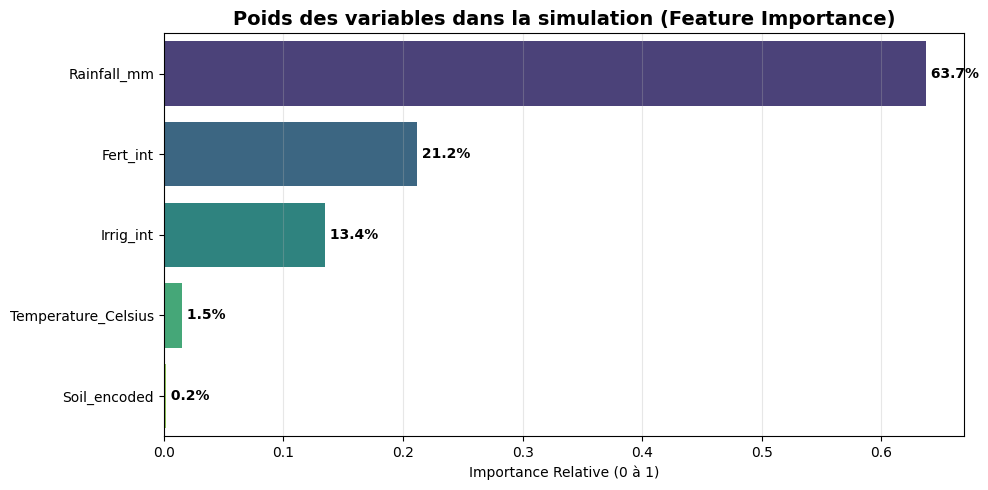

In [88]:
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd # Au cas où

print("\n=== ANALYSE FEATURE IMPORTANCE (RANDOM FOREST) ===\n")

# 1. Entraînement rapide (On réutilise X_train et y_train de l'étape précédente)
# n_estimators=50 suffit largement pour avoir une tendance
rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)

# 2. Extraction des importances
importances = pd.DataFrame({
    'Feature': X.columns,  # On récupère les noms des colonnes de X
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 3. Visualisation
plt.figure(figsize=(10, 5))
# Palette 'viridis' ou 'magma' pour faire ressortir les forts
sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis')

plt.title("Poids des variables dans la simulation (Feature Importance)", fontsize=14, fontweight='bold')
plt.xlabel("Importance Relative (0 à 1)")
plt.ylabel("")
plt.grid(axis='x', alpha=0.3)

# Affichage des pourcentages au bout des barres
for index, row in enumerate(importances.itertuples()):
    plt.text(row.Importance, index, f' {row.Importance:.1%}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

L'utilisation d'un modèle non-linéaire (Random Forest) nous permet de trancher définitivement sur la hiérarchie des facteurs dans ce simulateur :

1.  **L'Hégémonie de l'Eau (Water-Driven Model) :**
    * L'hydrométrie est le facteur déterminant absolu. En cumulant **Rainfall (63.7%)** et **Irrigation (13.4%)**, l'apport en eau explique près de **77%** de la variance du rendement.
    
2.  **L'Impact des Intrants :**
    * L'engrais (**Fertilizer**) joue un rôle majeur de soutien (**21.2%**), confirmant la logique agronomique "intrants = rendement".

3.  **La "Simplification" Thermique :**
    * Avec seulement **1.5%** d'importance, la **Température** est relayée au second plan par le simulateur.
    * **Analyse critique :** Contrairement à la réalité biologique où une température extrême peut détruire une récolte (effet seuil), ce dataset synthétique semble avoir été généré avec une formule où la température est un facteur d'ajustement mineur, loin derrière l'eau.

**✅ Conclusion pour la modélisation :** Notre futur système de recommandation sera extrêmement sensible aux variations de pluie. La température servira de variable d'ajustement fine, mais ne sera pas le "driver" principal. Cela valide notre choix d'une tolérance stricte sur la température lors de la fusion, pour ne pas introduire de bruit inutile sur une variable déjà faible.

### Granularité Rainfall/Temperature

In [89]:
n_combinations.head()

Crop    Soil_Type  Fertilizer_Used  Irrigation_Used
Barley  Chalky     False            False              7072
                                    True               6968
                   True             False              6755
                                    True               6937
        Clay       False            False              7110
dtype: int64

In [90]:
# Sélection 5 combinaisons exemple
sample_combinations = n_combinations.index[:5]


In [91]:
print(sample_combinations)

MultiIndex([('Barley', 'Chalky', False, False),
            ('Barley', 'Chalky', False,  True),
            ('Barley', 'Chalky',  True, False),
            ('Barley', 'Chalky',  True,  True),
            ('Barley',   'Clay', False, False)],
           names=['Crop', 'Soil_Type', 'Fertilizer_Used', 'Irrigation_Used'])


=== GRANULARITÉ RAINFALL ===



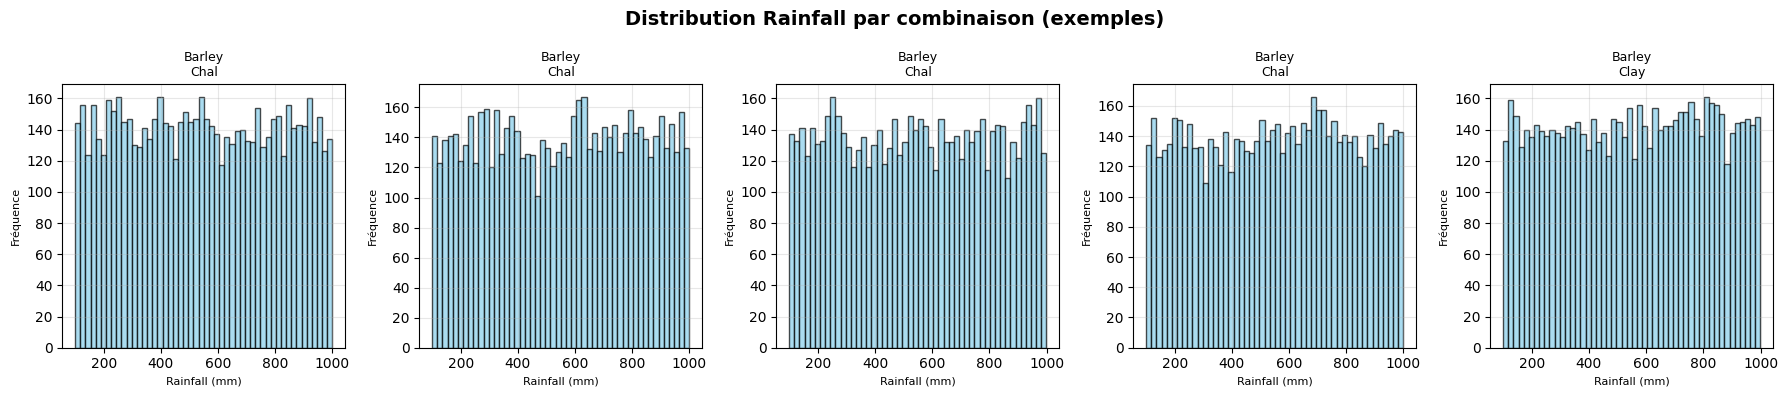

Rainfall global :
  Min : 100 mm
  Max : 1000 mm
  Plage : 900 mm
📊 Analyse de la variabilité Intra-Groupe :
  • Écart-type moyen de la pluie au sein d'un même groupe : 259.80 mm
  • Écart-type médian : 259.86 mm

✅ CONCLUSION : La variable est bien CONTINUE (Variabilité moyenne de ~260mm à conditions égales).

🎯 Tolérance Pluie calculée (1/2 Sigma) : ±130 mm


In [92]:
# Analyse granularité Rainfall
print("=== GRANULARITÉ RAINFALL ===\n")

# Sélection 5 combinaisons exemple
sample_combinations = n_combinations.index[:5]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for idx, combo in enumerate(sample_combinations):
    mask = (
        (df_cropyields['Crop'] == combo[0]) &
        (df_cropyields['Soil_Type'] == combo[1]) &
        (df_cropyields['Fertilizer_Used'] == combo[2]) &
        (df_cropyields['Irrigation_Used'] == combo[3])
    )
    
    df_sample = df_cropyields[mask]
    
    axes[idx].hist(df_sample['Rainfall_mm'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f"{combo[0]}\n{combo[1][:4]}", fontsize=9)
    axes[idx].set_xlabel('Rainfall (mm)', fontsize=8)
    axes[idx].set_ylabel('Fréquence', fontsize=8)
    axes[idx].grid(alpha=0.3)

plt.suptitle('Distribution Rainfall par combinaison (exemples)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Rainfall global :")
print(f"  Min : {df_cropyields['Rainfall_mm'].min():.0f} mm")
print(f"  Max : {df_cropyields['Rainfall_mm'].max():.0f} mm")
print(f"  Plage : {df_cropyields['Rainfall_mm'].max() - df_cropyields['Rainfall_mm'].min():.0f} mm")

# On calcule l'écart-type (la dispersion) de la pluie POUR CHAQUE combinaison unique

rain_variability = df_cropyields.groupby(['Crop', 'Soil_Type', 'Fertilizer_Used', 'Irrigation_Used'])['Rainfall_mm'].std()

# On regarde la moyenne de ces écarts-types
mean_variability = rain_variability.mean()
median_variability = rain_variability.median()

print(f"📊 Analyse de la variabilité Intra-Groupe :")
print(f"  • Écart-type moyen de la pluie au sein d'un même groupe : {mean_variability:.2f} mm")
print(f"  • Écart-type médian : {median_variability:.2f} mm")

# 3. Conclusion Dynamique
if mean_variability > 50: # Seuil arbitraire
    print(f"\n✅ CONCLUSION : La variable est bien CONTINUE (Variabilité moyenne de ~{mean_variability:.0f}mm à conditions égales).")
else:
    print(f"\n⚠️ ATTENTION : La variable semble CONSTANTE ou DISCRÈTE par groupe.")

RAIN_TOLERANCE = round(mean_variability / 2)
print(f"\n🎯 Tolérance Pluie calculée (1/2 Sigma) : ±{RAIN_TOLERANCE} mm")

=== GRANULARITÉ TEMPERATURE ===



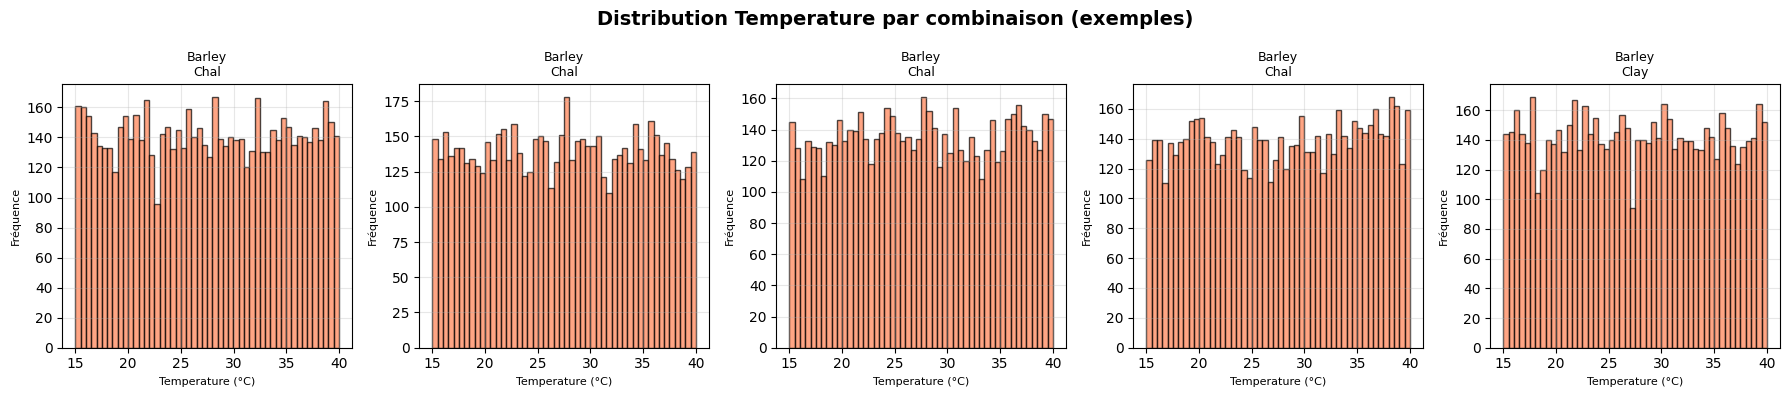

Temperature globale :
  Min : 15°C
  Max : 40°C
  Plage : 25°C
📊 Analyse de la variabilité Intra-Groupe :
  • Écart-type moyen de la température au sein d'un même groupe : 7.22°C
  • Écart-type médian : 7.22°C

✅ CONCLUSION : La variable est bien CONTINUE (Variabilité moyenne de ~7°C à conditions égales).

🎯 Tolérance Temp calculée (Conservatrice, 1/3 Sigma) : ±2.4 °C


In [93]:
# Analyse granularité Temperature
print("=== GRANULARITÉ TEMPERATURE ===\n")

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for idx, combo in enumerate(sample_combinations):
    mask = (
        (df_cropyields['Crop'] == combo[0]) &
        (df_cropyields['Soil_Type'] == combo[1]) &
        (df_cropyields['Fertilizer_Used'] == combo[2]) &
        (df_cropyields['Irrigation_Used'] == combo[3])
    )
    
    df_sample = df_cropyields[mask]
    
    axes[idx].hist(df_sample['Temperature_Celsius'], bins=50, color='coral', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f"{combo[0]}\n{combo[1][:4]}", fontsize=9)
    axes[idx].set_xlabel('Temperature (°C)', fontsize=8)
    axes[idx].set_ylabel('Fréquence', fontsize=8)
    axes[idx].grid(alpha=0.3)

plt.suptitle('Distribution Temperature par combinaison (exemples)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Temperature globale :")
print(f"  Min : {df_cropyields['Temperature_Celsius'].min():.0f}°C")
print(f"  Max : {df_cropyields['Temperature_Celsius'].max():.0f}°C")
print(f"  Plage : {df_cropyields['Temperature_Celsius'].max() - df_cropyields['Temperature_Celsius'].min():.0f}°C")

# On calcule l'écart-type (la dispersion) de la pluie POUR CHAQUE combinaison unique

temp_variability = df_cropyields.groupby(['Crop', 'Soil_Type', 'Fertilizer_Used', 'Irrigation_Used'])['Temperature_Celsius'].std()

# On regarde la moyenne de ces écarts-types
mean_variability = temp_variability.mean()
median_variability = temp_variability.median()

print(f"📊 Analyse de la variabilité Intra-Groupe :")
print(f"  • Écart-type moyen de la température au sein d'un même groupe : {mean_variability:.2f}°C")
print(f"  • Écart-type médian : {median_variability:.2f}°C")

# 3. Conclusion Dynamique
if mean_variability > 1: # Seuil arbitraire
    print(f"\n✅ CONCLUSION : La variable est bien CONTINUE (Variabilité moyenne de ~{mean_variability:.0f}°C à conditions égales).")
else:
    print(f"\n⚠️ ATTENTION : La variable semble CONSTANTE ou DISCRÈTE par groupe.")

TEMP_TOLERANCE = round(mean_variability / 3, 1) # Diviseur 3 pour être conservateur
print(f"\n🎯 Tolérance Temp calculée (Conservatrice, 1/3 Sigma) : ±{TEMP_TOLERANCE} °C")

### Impact des sols

C:\Users\Fab\AppData\Local\Temp\ipykernel_11828\4232586366.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


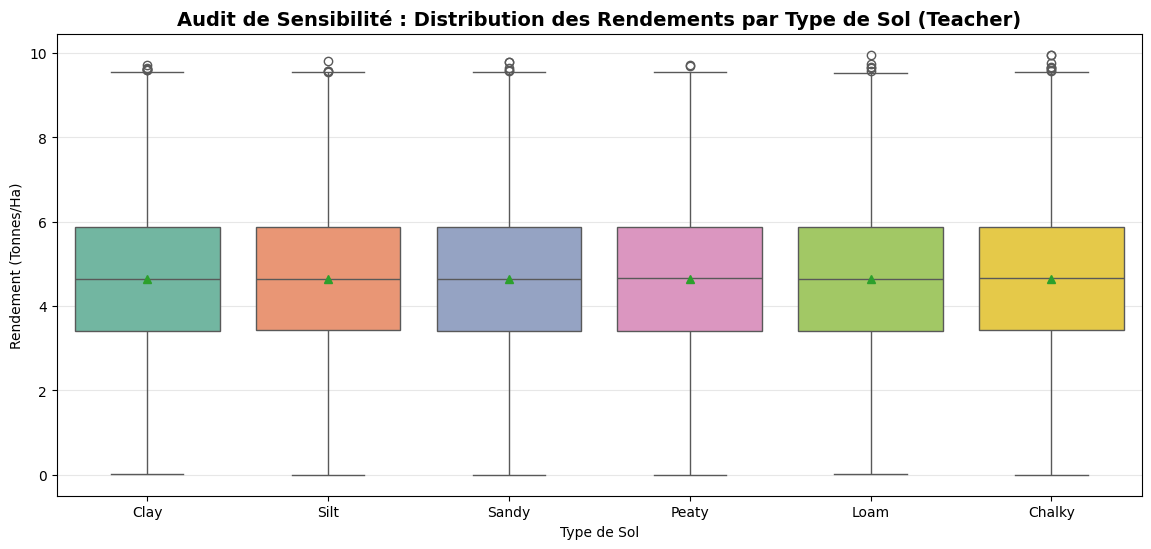

📊 ANALYSE STATISTIQUE RAPIDE :
-> Rendement Moyen Minimum (Sol 'Clay') : 4.6461 t/ha
-> Rendement Moyen Maximum (Sol 'Chalky') : 4.6542 t/ha
-> Variation relative entre le pire et le meilleur sol : 0.173630 %
------------------------------------------------------------
🚩 VERDICT : IMPACT NÉGLIGEABLE OU NUL.
   Les boîtes sont alignées. Le simulateur n'a pas modélisé l'effet du sol.


In [94]:
# ==============================================================================
# AUDIT VISUEL : IMPACT DU SOL (BOXPLOTS)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcul de l'ordre (pour voir s'il y a une hiérarchie logique)
# On trie les sols du moins productif au plus productif (en théorie)
order_sols = df_cropyields.groupby('Soil_Type')['Yield_tons_per_hectare'].mean().sort_values().index

plt.figure(figsize=(14, 6))

# 2. Création du Boxplot
sns.boxplot(
    data=df_cropyields, 
    x='Soil_Type', 
    y='Yield_tons_per_hectare', 
    order=order_sols,
    palette="Set2",     # Couleurs distinctes pour bien séparer
    showmeans=True      # Affiche un petit triangle pour la moyenne exacte
)

plt.title("Audit de Sensibilité : Distribution des Rendements par Type de Sol (Teacher)", fontsize=14, fontweight='bold')
plt.ylabel("Rendement (Tonnes/Ha)")
plt.xlabel("Type de Sol")
plt.grid(True, alpha=0.3, axis='y')

# 3. Affichage des statistiques exactes pour confirmation
means = df_cropyields.groupby('Soil_Type')['Yield_tons_per_hectare'].mean()
ecart_max = means.max() - means.min()
variation_pct = (ecart_max / means.mean()) * 100

plt.show()

print(f"📊 ANALYSE STATISTIQUE RAPIDE :")
print(f"-> Rendement Moyen Minimum (Sol '{means.idxmin()}') : {means.min():.4f} t/ha")
print(f"-> Rendement Moyen Maximum (Sol '{means.idxmax()}') : {means.max():.4f} t/ha")
print(f"-> Variation relative entre le pire et le meilleur sol : {variation_pct:.6f} %")
print("-" * 60)

if variation_pct < 1.0:
    print("🚩 VERDICT : IMPACT NÉGLIGEABLE OU NUL.")
    print("   Les boîtes sont alignées. Le simulateur n'a pas modélisé l'effet du sol.")
else:
    print("✅ VERDICT : IMPACT SIGNIFICATIF DÉTECTÉ.")

### Harmonisation et Réduction du Périmètre d'Analyse

**Démarche :**
1. **Standardisation de la nomenclature :** Alignement des termes de la FAO (`Rice, paddy`, `Soybeans`) sur les termes standards (`Rice`, `Soybean`).
2. **Filtrage :** Exclusion des cultures non communes.
3. **Validation :** Contrôle de la volumétrie avant/après pour s'assurer de conserver une masse de données statistiquement représentative.

In [95]:
# 1. Standardisation des noms de cultures dans le dataset FAO
dictionnaire_mapping = {
    'Rice, paddy': 'Rice',
    'Soybeans': 'Soybean'
}

# On applique le mapping. Les cultures non listées dans le dico gardent leur nom d'origine.
df_fao_consolidated['Item'] = df_fao_consolidated['Item'].replace(dictionnaire_mapping)

# Vérification rapide de l'alignement
print("Nouvelles catégories FAO :", df_fao_consolidated['Item'].unique())

Nouvelles catégories FAO : ['Maize' 'Potatoes' 'Rice' 'Sorghum' 'Soybean' 'Wheat' 'Cassava'
 'Sweet potatoes' 'Plantains and others' 'Yams']


Les nomenclatures étant désormais alignées, nous appliquons le masque de filtrage sur nos deux jeux de données et documentons la perte de volumétrie.

In [96]:
# 2. Définition du périmètre cible
cultures_cibles = ['Maize', 'Wheat', 'Rice', 'Soybean']

# Stockage des dimensions initiales pour le reporting
fao_shape_initial = df_fao_consolidated.shape
hist_shape_initial = df_cropyields.shape

# 3. Filtrage (avec .copy() pour éviter les SettingWithCopyWarning de Pandas par la suite)
df_fao_consolidated = df_fao_consolidated[df_fao_consolidated['Item'].isin(cultures_cibles)].copy()
df_cropyields = df_cropyields[df_cropyields['Crop'].isin(cultures_cibles)].copy()

# 4. Reporting de la réduction
print("=== RÉDUCTION DU PÉRIMÈTRE AUX 4 CULTURES COMMUNES ===")
print(f"🌽 Cultures retenues : {cultures_cibles}\n")

print("[DATASET FAO]")
print(f"-> Lignes avant filtrage : {fao_shape_initial[0]}")
print(f"-> Lignes après filtrage : {df_fao_consolidated.shape[0]}")
print(f"-> Taux de conservation : {(df_fao_consolidated.shape[0] / fao_shape_initial[0]) * 100:.1f} %\n")

print("[DATASET Crop Yield (Simulateur)]")
print(f"-> Lignes avant filtrage : {hist_shape_initial[0]}")
print(f"-> Lignes après filtrage : {df_cropyields.shape[0]}")
print(f"-> Taux de conservation : {(df_cropyields.shape[0] / hist_shape_initial[0]) * 100:.1f} %")

=== RÉDUCTION DU PÉRIMÈTRE AUX 4 CULTURES COMMUNES ===
🌽 Cultures retenues : ['Maize', 'Wheat', 'Rice', 'Soybean']

[DATASET FAO]
-> Lignes avant filtrage : 13030
-> Lignes après filtrage : 6532
-> Taux de conservation : 50.1 %

[DATASET Crop Yield (Simulateur)]
-> Lignes avant filtrage : 999769
-> Lignes après filtrage : 666494
-> Taux de conservation : 66.7 %


# Analyse en Composantes Principales (ACP) & Comparaison Structurelle des deux datasets

**Objectif :** L'objectif de cette section est de réaliser un **audit structurel** pour vérifier si les lois mathématiques et agronomiques du dataset FAO (monde réel) correspondent à celles du dataset Crop Yield (simulateur). 

**Préparation des données :**
Pour le dataset Crop Yield, nous intégrons les pratiques agricoles (`Fertilizer_Used` et `Irrigation_Used`) en les binarisant (0/1) afin qu'elles soient lisibles par l'ACP. Nous conserverons `pesticides_tonnes` pour la FAO. L'enjeu est d'observer si ces vecteurs d'intrants pointent dans la même direction par rapport au rendement, ce qui justifierait la création d'un proxy commun.

L'analyse sera menée culture par culture pour éviter le bruit statistique.

In [97]:
# 1. Binarisation des variables de pratiques agricoles (Crop Yield)
# On utilise un replace large pour capturer les booléens ou les strings ('Yes'/'No', 'True'/'False')
mapping_bool = {True: 1, False: 0, 'True': 1, 'False': 0, 'Yes': 1, 'No': 0}
df_cropyields['Fertilizer_Used'] = df_cropyields['Fertilizer_Used'].replace(mapping_bool).astype(int)
df_cropyields['Irrigation_Used'] = df_cropyields['Irrigation_Used'].replace(mapping_bool).astype(int)

# 2. Définition des colonnes cibles
cols_fao = ['yield_hg_per_ha', 'average_rain_fall_mm_per_year', 'avg_temp', 'pesticides_tonnes']
cols_hist = ['Yield_tons_per_hectare', 'Rainfall_mm', 'Temperature_Celsius', 'Days_to_Harvest', 'Fertilizer_Used', 'Irrigation_Used']

# 3. Fonction utilitaire pour tracer les cercles de corrélation
def plot_correlation_circle(pca, features, ax, title, variance_ratios):
    circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
    ax.add_patch(circle)
    
    for i, (feature, comp1, comp2) in enumerate(zip(features, pca.components_[0, :], pca.components_[1, :])):
        ax.arrow(0, 0, comp1, comp2, head_width=0.05, head_length=0.05, color='b', alpha=0.8)
        # Ajustement du texte pour éviter la superposition
        ax.text(comp1 * 1.15, comp2 * 1.15, feature, color='black', ha='center', va='center', fontsize=9)
    
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_xlabel(f"PC1 ({variance_ratios[0]:.1f}%)")
    ax.set_ylabel(f"PC2 ({variance_ratios[1]:.1f}%)")
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)

C:\Users\Fab\AppData\Local\Temp\ipykernel_11828\702775467.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cropyields['Fertilizer_Used'] = df_cropyields['Fertilizer_Used'].replace(mapping_bool).astype(int)
C:\Users\Fab\AppData\Local\Temp\ipykernel_11828\702775467.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cropyields['Irrigation_Used'] = df_cropyields['Irrigation_Used'].replace(mapping_bool).astype(int)


## Audit Structurel : Le Maïs (Maize)

### Cercles de corrélation

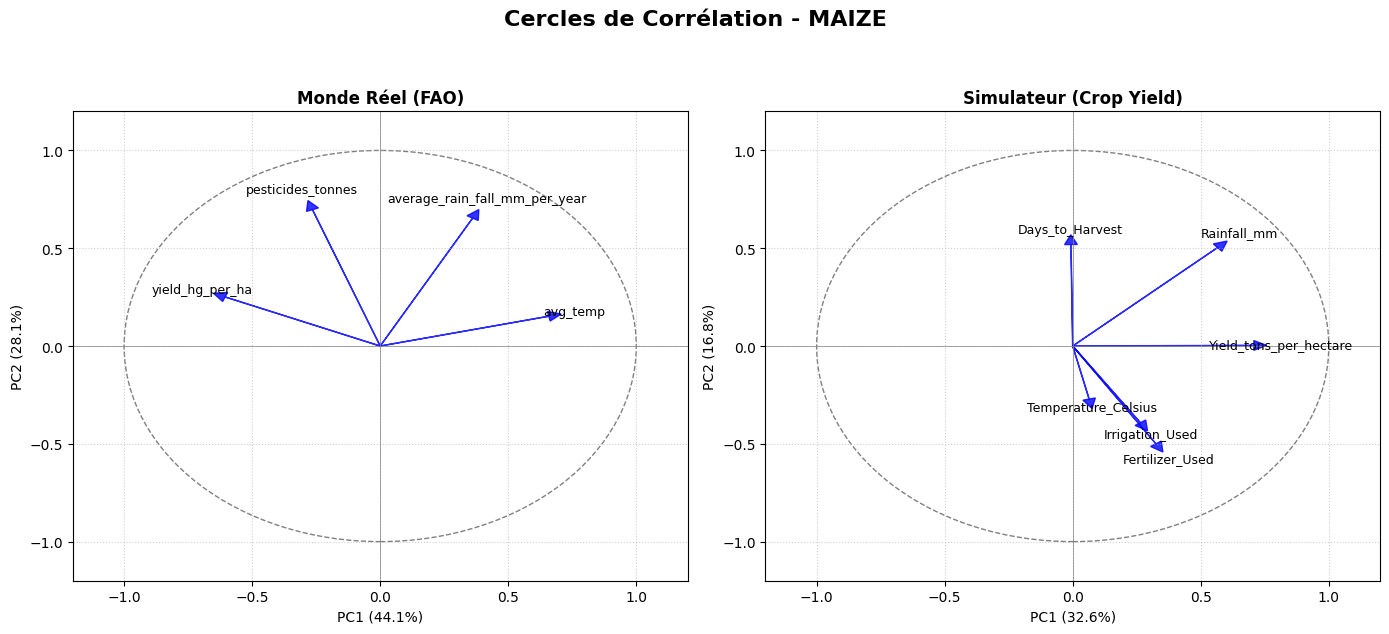

🔍 DIAGNOSTIC NUMÉRIQUE : MAIZE 🔍

[MONDE RÉEL - FAO]
Variance (PC1+PC2) = 72.2 %
                     Variable  PC1_Coord  PC2_Coord  Corr_Pearson_Yield
              yield_hg_per_ha     -0.606      0.251               1.000
average_rain_fall_mm_per_year      0.361      0.654              -0.083
                     avg_temp      0.658      0.152              -0.559
            pesticides_tonnes     -0.264      0.697               0.244

--------------------------------------------------

[SIMULATEUR - Crop Yield]
Variance (PC1+PC2) = 49.3 %
              Variable  PC1_Coord  PC2_Coord  Corr_Pearson_Yield
Yield_tons_per_hectare      0.707      0.003               1.000
           Rainfall_mm      0.566      0.503               0.765
   Temperature_Celsius      0.064     -0.271               0.085
       Days_to_Harvest     -0.007      0.519              -0.005
       Fertilizer_Used      0.325     -0.500               0.440
       Irrigation_Used      0.264     -0.392               0.3

In [98]:
culture = 'Maize'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Cercles de Corrélation - {culture.upper()}", fontsize=16, fontweight='bold', y=1.05)

# ==========================================
# 1. MONDE RÉEL (FAO)
# ==========================================
df_fao_sub = df_fao_consolidated[df_fao_consolidated['Item'] == culture][cols_fao].dropna()

scaler_fao = StandardScaler()
X_fao_scaled = scaler_fao.fit_transform(df_fao_sub)
pca_fao = PCA(n_components=2)
pca_fao.fit(X_fao_scaled)

plot_correlation_circle(pca_fao, cols_fao, axes[0], "Monde Réel (FAO)", pca_fao.explained_variance_ratio_ * 100)

# Diagnostic numérique FAO
df_vecteurs_fao = pd.DataFrame({
    'Variable': cols_fao,
    'PC1_Coord': pca_fao.components_[0, :],
    'PC2_Coord': pca_fao.components_[1, :]
})
df_vecteurs_fao['Corr_Pearson_Yield'] = df_fao_sub.corr()['yield_hg_per_ha'].values

# ==========================================
# 2. SIMULATEUR (Crop Yield)
# ==========================================
df_hist_sub = df_cropyields[df_cropyields['Crop'] == culture][cols_hist].dropna()

scaler_hist = StandardScaler()
X_hist_scaled = scaler_hist.fit_transform(df_hist_sub)
pca_hist = PCA(n_components=2)
pca_hist.fit(X_hist_scaled)

plot_correlation_circle(pca_hist, cols_hist, axes[1], "Simulateur (Crop Yield)", pca_hist.explained_variance_ratio_ * 100)

# Diagnostic numérique Crop Yield
df_vecteurs_hist = pd.DataFrame({
    'Variable': cols_hist,
    'PC1_Coord': pca_hist.components_[0, :],
    'PC2_Coord': pca_hist.components_[1, :]
})
df_vecteurs_hist['Corr_Pearson_Yield'] = df_hist_sub.corr()['Yield_tons_per_hectare'].values

plt.tight_layout()
plt.show()

# ==========================================
# AFFICHAGE DU DIAGNOSTIC (À COPIER DANS LE CHAT)
# ==========================================
print(f"🔍 DIAGNOSTIC NUMÉRIQUE : {culture.upper()} 🔍\n")
print("[MONDE RÉEL - FAO]")
print(f"Variance (PC1+PC2) = {(pca_fao.explained_variance_ratio_[0] + pca_fao.explained_variance_ratio_[1])*100:.1f} %")
print(df_vecteurs_fao.round(3).to_string(index=False))
print("\n" + "-" * 50 + "\n")
print("[SIMULATEUR - Crop Yield]")
print(f"Variance (PC1+PC2) = {(pca_hist.explained_variance_ratio_[0] + pca_hist.explained_variance_ratio_[1])*100:.1f} %")
print(df_vecteurs_hist.round(3).to_string(index=False))

#### Analyse

**1. Observations sur le Monde Réel (Dataset FAO)**
* La variance expliquée par les deux premiers axes est très bonne (72.2%).
* **Sensibilité thermique :** On observe une forte opposition (corrélation Pearson de -0.559) entre le Rendement (`yield`) et la Température (`avg_temp`). Cela traduit la réalité agronomique : le maïs souffre des fortes chaleurs (échaudage).
* **Dynamique des intrants :** Les vecteurs Précipitations et Pesticides partagent une direction proche, illustrant le phénomène de "lessivage" (les fortes pluies lavent les traitements, nécessitant de nouvelles applications).

**2. Observations sur le Simulateur (Dataset Crop Yield) : Preuve de Synthèse**
L'ajout des variables de pratiques agricoles (`Fertilizer_Used`, `Irrigation_Used`) met en lumière la nature artificielle de ce jeu de données :
* **Combinaison Linéaire :** Visuellement, le vecteur `Yield` agit comme la résultante (la somme vectorielle) des vecteurs `Rainfall` et `Fertilizer/Irrigation`. Cela indique que le rendement a été généré via une équation mathématique simple (linéaire) additive.
* **Incohérence Agronomique :** Les vecteurs `Rainfall` et `Irrigation_Used` sont orthogonaux (indépendants). Dans la réalité, ces variables sont fortement anticorrélées (on n'irrigue pas quand il pleut). Le simulateur a tiré ces paramètres de façon aléatoire et indépendante.
* **Corrélation Température / Maturité :** Le seul lien logique conservé est la relation inverse entre `Temperature` et `Days_to_Harvest` : plus il fait chaud, plus la plante accumule vite ses degrés-jours, réduisant le temps avant récolte.

**3. Conclusion Stratégique**
Les relations de cause à effet (les angles entre les variables) sont fondamentalement différentes entre le monde réel (FAO) et le simulateur (Crop Yield). 
**Décision :** La création de proxys directs par fusion est mathématiquement invalidée. Nous conservons notre choix d'une architecture hybride où le dataset Crop yield servira uniquement à extraire des coefficients isolés (règles métier).

## Audit Structurel : Le Blé (Wheat)

### Cercles de corrélation

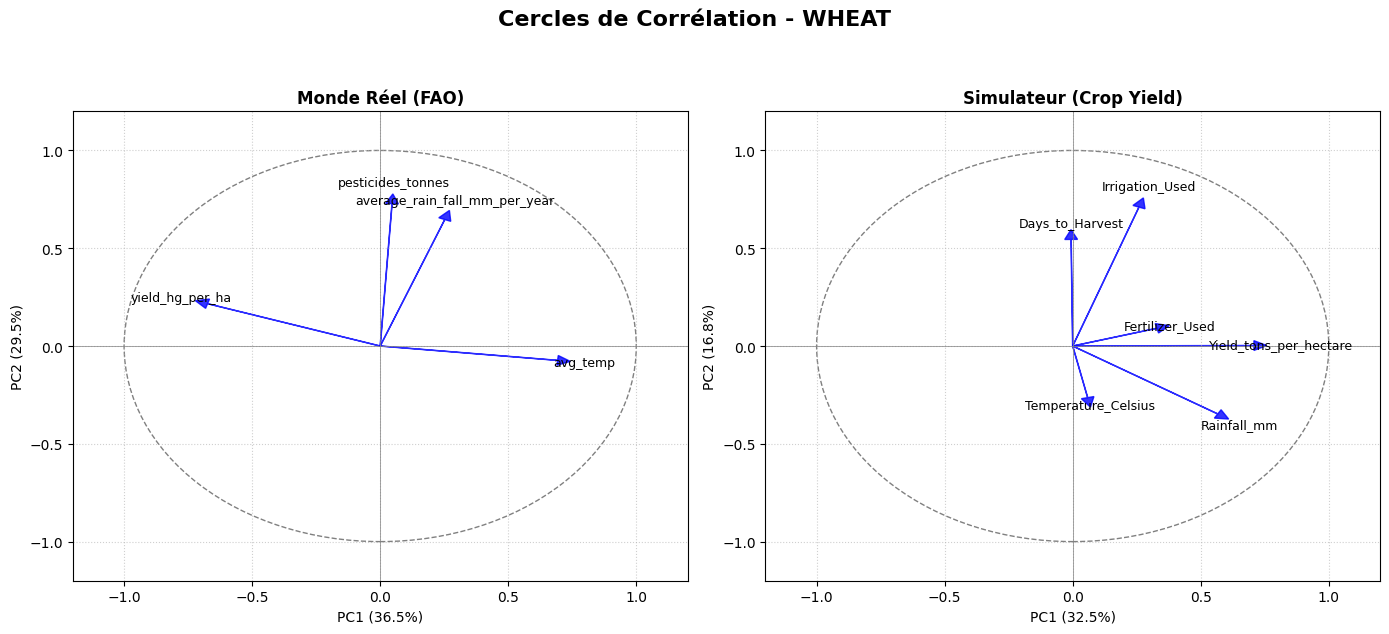

🔍 DIAGNOSTIC NUMÉRIQUE : WHEAT 🔍

[MONDE RÉEL - FAO]
Variance (PC1+PC2) = 66.0 %
                     Variable  PC1_Coord  PC2_Coord  Corr_Pearson_Yield
              yield_hg_per_ha     -0.674      0.216               1.000
average_rain_fall_mm_per_year      0.252      0.647              -0.052
                     avg_temp      0.693     -0.073              -0.432
            pesticides_tonnes      0.046      0.728               0.057

--------------------------------------------------

[SIMULATEUR - Crop Yield]
Variance (PC1+PC2) = 49.3 %
              Variable  PC1_Coord  PC2_Coord  Corr_Pearson_Yield
Yield_tons_per_hectare      0.708      0.002               1.000
           Rainfall_mm      0.566     -0.347               0.764
   Temperature_Celsius      0.058     -0.264               0.082
       Days_to_Harvest     -0.006      0.545              -0.004
       Fertilizer_Used      0.329      0.091               0.443
       Irrigation_Used      0.259      0.710               0.3

In [99]:
culture = 'Wheat'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Cercles de Corrélation - {culture.upper()}", fontsize=16, fontweight='bold', y=1.05)

# ==========================================
# 1. MONDE RÉEL (FAO)
# ==========================================
df_fao_sub = df_fao_consolidated[df_fao_consolidated['Item'] == culture][cols_fao].dropna()

scaler_fao = StandardScaler()
X_fao_scaled = scaler_fao.fit_transform(df_fao_sub)
pca_fao = PCA(n_components=2)
pca_fao.fit(X_fao_scaled)

plot_correlation_circle(pca_fao, cols_fao, axes[0], "Monde Réel (FAO)", pca_fao.explained_variance_ratio_ * 100)

# Diagnostic numérique FAO
df_vecteurs_fao = pd.DataFrame({
    'Variable': cols_fao,
    'PC1_Coord': pca_fao.components_[0, :],
    'PC2_Coord': pca_fao.components_[1, :]
})
df_vecteurs_fao['Corr_Pearson_Yield'] = df_fao_sub.corr()['yield_hg_per_ha'].values

# ==========================================
# 2. SIMULATEUR (Crop Yield)
# ==========================================
df_hist_sub = df_cropyields[df_cropyields['Crop'] == culture][cols_hist].dropna()

scaler_hist = StandardScaler()
X_hist_scaled = scaler_hist.fit_transform(df_hist_sub)
pca_hist = PCA(n_components=2)
pca_hist.fit(X_hist_scaled)

plot_correlation_circle(pca_hist, cols_hist, axes[1], "Simulateur (Crop Yield)", pca_hist.explained_variance_ratio_ * 100)

# Diagnostic numérique Crop Yield
df_vecteurs_hist = pd.DataFrame({
    'Variable': cols_hist,
    'PC1_Coord': pca_hist.components_[0, :],
    'PC2_Coord': pca_hist.components_[1, :]
})
df_vecteurs_hist['Corr_Pearson_Yield'] = df_hist_sub.corr()['Yield_tons_per_hectare'].values

plt.tight_layout()
plt.show()

# ==========================================
# AFFICHAGE DU DIAGNOSTIC (À COPIER DANS LE CHAT)
# ==========================================
print(f"🔍 DIAGNOSTIC NUMÉRIQUE : {culture.upper()} 🔍\n")
print("[MONDE RÉEL - FAO]")
print(f"Variance (PC1+PC2) = {(pca_fao.explained_variance_ratio_[0] + pca_fao.explained_variance_ratio_[1])*100:.1f} %")
print(df_vecteurs_fao.round(3).to_string(index=False))
print("\n" + "-" * 50 + "\n")
print("[SIMULATEUR - Crop Yield]")
print(f"Variance (PC1+PC2) = {(pca_hist.explained_variance_ratio_[0] + pca_hist.explained_variance_ratio_[1])*100:.1f} %")
print(df_vecteurs_hist.round(3).to_string(index=False))

#### Analyse

**1. Observations sur le Monde Réel (Dataset FAO)**
* **Le stress thermique confirmé :** Tout comme pour le maïs, le facteur limitant principal pour le blé à l'échelle mondiale est la température (Corrélation de Pearson de -0.432). Le vecteur `avg_temp` s'oppose au vecteur `yield`. C'est cohérent : le blé est une culture tempérée qui supporte mal les excès de chaleur.
* **La complexité de l'eau :** Contrairement au simulateur, la corrélation directe entre Pluie annuelle et Rendement est quasi nulle (-0.052). Cela s'explique par la grande diversité des types de blé (hiver vs printemps) et le fait que l'excès d'eau est aussi néfaste (maladies fongiques) que le manque.

**2. Observations sur le Simulateur (Crop Yield) : La "Formule Unique"**
L'analyse du blé confirme le diagnostic posé sur le maïs. Les structures mathématiques sont **strictement identiques**, ce qui est biologiquement impossible (le blé et le maïs ont des besoins radicalement différents).
* **Répétition de l'Algorithme :** La corrélation Pluie/Rendement est de 0.764, soit quasiment la même valeur que pour le maïs (0.765). Le simulateur applique la même "formule magique" linéaire indépendamment de l'espèce végétale.
* **Cécité Thermique :** Alors que le dataset FAO montre que la température est un facteur critique (-0.432), le simulateur considère que la température n'a aucun impact (0.082).
* **Additivité :** On retrouve la même construction vectorielle où `Yield` semble être la somme directe de `Rainfall` + `Fertilizer` + `Irrigation`.

**3. Conclusion Stratégique**
Le dataset Crop Yield échoue à capturer la spécificité biologique du blé, notamment sa sensibilité à la température et sa relation complexe à l'eau.
**Décision :** Impossible d'utiliser les données climatiques Crop Yield pour entraîner un modèle prédictif fiable. Nous validons l'approche par séparation : FAO pour le climat, Crop Yield uniquement pour les bonus/malus (Sol/Intrants).

**Note sur l'exhaustivité (Riz et Soja) :** Les cercles de corrélations générés ci-dessous pour les deux dernières cultures (Riz et Soja) ont pour seul but l'exhaustivité visuelle. Ils confirment strictement le diagnostic précédent : le simulateur affiche une variance identique (49.3%) et les mêmes structures vectorielles génériques. Il est donc inutile d'alourdir l'analyse avec un décorticage redondant. La preuve de la nature artificielle et "copiée-collée" du dataset Crop Yield est définitivement acquise, ce qui valide notre choix d'une architecture hybride.

## Audit Structurel : Riz et Soja

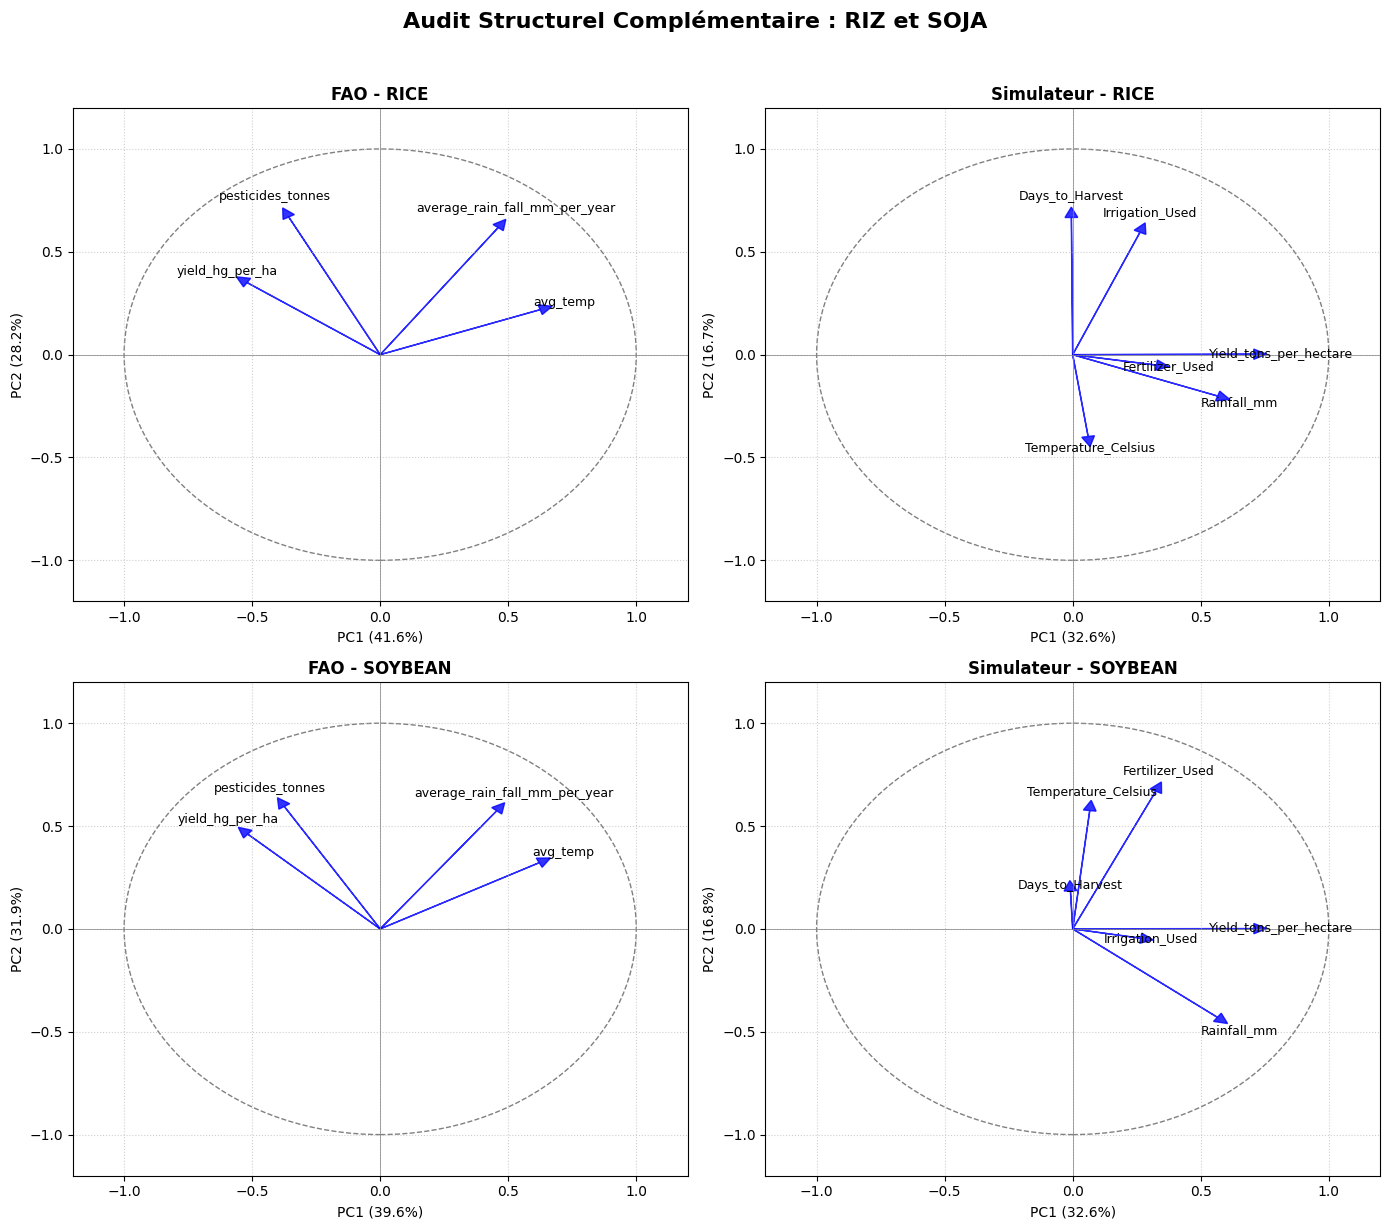

✅ Étape d'audit visuel terminée. Les structures génériques de Crop Yield sont confirmées.


In [100]:
# ==========================================
# 6.3 Génération condensée pour exhaustivité (Riz & Soja)
# ==========================================
cultures_restantes = ['Rice', 'Soybean']

# Création d'une grille 2x2 (2 lignes pour les cultures, 2 colonnes pour FAO/Hist)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Audit Structurel Complémentaire : RIZ et SOJA", fontsize=16, fontweight='bold', y=1.02)

for i, culture in enumerate(cultures_restantes):
    # --- MONDE RÉEL (FAO) ---
    df_fao_sub = df_fao_consolidated[df_fao_consolidated['Item'] == culture][cols_fao].dropna()
    scaler_fao = StandardScaler()
    X_fao_scaled = scaler_fao.fit_transform(df_fao_sub)
    pca_fao = PCA(n_components=2)
    pca_fao.fit(X_fao_scaled)
    
    # Tracé sur la première colonne (axes[i, 0])
    plot_correlation_circle(
        pca_fao, cols_fao, axes[i, 0], 
        f"FAO - {culture.upper()}", 
        pca_fao.explained_variance_ratio_ * 100
    )
    
    # --- SIMULATEUR (Crop Yield) ---
    df_hist_sub = df_cropyields[df_cropyields['Crop'] == culture][cols_hist].dropna()
    scaler_hist = StandardScaler()
    X_hist_scaled = scaler_hist.fit_transform(df_hist_sub)
    pca_hist = PCA(n_components=2)
    pca_hist.fit(X_hist_scaled)
    
    # Tracé sur la deuxième colonne (axes[i, 1])
    plot_correlation_circle(
        pca_hist, cols_hist, axes[i, 1], 
        f"Simulateur - {culture.upper()}", 
        pca_hist.explained_variance_ratio_ * 100
    )

plt.tight_layout()
plt.show()

print("✅ Étape d'audit visuel terminée. Les structures génériques de Crop Yield sont confirmées.")

## Granularité climatique du dataset FAO

In [101]:
df_fao_consolidated.columns

Index(['Area', 'Item', 'Year', 'yield_hg_per_ha',
       'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'],
      dtype='object')

In [102]:
# Vérification de la variance de la température par culture pour le Brésil en 2013
display(df_fao_consolidated.loc[(df_fao_consolidated['Area'] == 'Brazil') & (df_fao_consolidated['Year'] == 2013), ['Item', 'avg_temp']])

,Item,avg_temp
1432,Maize,22.478182
1478,Rice,22.478182
1524,Soybean,22.478182
1570,Wheat,22.478182


In [103]:
# Vérification de la variance de la pluie par culture pour le Brésil en 2013
display(df_fao_consolidated.loc[(df_fao_consolidated['Area'] == 'Brazil') & (df_fao_consolidated['Year'] == 2013), ['Item', 'average_rain_fall_mm_per_year']])

,Item,average_rain_fall_mm_per_year
1432,Maize,1761.0
1478,Rice,1761.0
1524,Soybean,1761.0
1570,Wheat,1761.0


**Conclusion sur la granularité climatique**
Une vérification sur des échantillons (ex: Brésil 2013) démontre que les variables climatiques de la FAO (`avg_temp`, `average_rain_fall_mm_per_year`) sont des moyennes nationales strictes. Elles ne varient pas en fonction de la culture (`Item`). 
**Décision architecturale :** Lors de la création de la Table de Référence Climatique pour l'application finale, l'agrégation se fera uniquement par Pays (`Area`), ce qui allégera la charge en mémoire du tableau de référence.

# Synthèse Analytique et Réponse aux Objectifs du Projet

## Confrontation avec le cahier des charges initial
Le cahier des charges initial (cf. briefing du Lead Data Scientist) posait les hypothèses suivantes concernant nos deux sources de données :
> *"Agriculture CropYield Dataset : Données historiques de rendement [...]"*
> *"CropYield Prediction Dataset : Données agronomiques et climatiques (usage de pesticides, fertilisants, température...)"*

Cependant, l'Analyse en Composantes Principales (ACP) a permis de poser un diagnostic technique différent sur la réalité de ces jeux de données :

**1. Le "Agriculture CropYield Dataset" n'est pas un relevé d'observations.**
L'analyse de sa variance (répartition parfaite et symétrique) et l'orthogonalité de ses vecteurs climatiques démontrent qu'il s'agit d'un **dataset généré de manière synthétique** (un simulateur). il applique des formules mathématiques linéaires rigides et déconnectées de la biologie.

**2. Le "CropYield Prediction Dataset" (FAO) est la véritable source de vérité terrain.**
Contrairement au postulat initial, c'est ce dataset qui contient les véritables dynamiques historiques mondiales. Ses corrélations traduisent les vrais phénomènes agronomiques (ex: sensibilité du maïs aux fortes chaleurs, impact des précipitations sur l'usage des pesticides). Toutefois, comme relevé lors de l'audit, il ne contient pas l'information sur l'usage des fertilisants, l'irrigation ou les types de sols.

### 7.2. Justification de l'Architecture Hybride retenue
L'énoncé précise : *"Tu es libre de choisir la manière d'exploiter ces deux jeux de données [...] L’important est de justifier clairement tes choix et d’optimiser la performance et l’interprétabilité"*.

Face à l'impossibilité mathématique de fusionner un monde réel (FAO) avec un simulateur synthétique (Crop Yield) sous peine de corrompre l'apprentissage de l'algorithme, nous optons pour une **Architecture Hybride Modulaire** :

* **Le Modèle d'Apprentissage (Machine Learning) :** Il sera entraîné **exclusivement sur les données FAO** enrichies de variables de stress agronomique. Cela garantit que le modèle apprend la véritable physique du climat sur les plantes.
* **Le Moteur de Règles (Post-Processing) :** Le dataset Crop Yield synthétique ne sera pas jeté. Il sera utilisé pour extraire les coefficients d'impact des pratiques agricoles (Sol, Irrigation, Fertilisants). 

**Avantage MLOps :** Cette séparation permet de mettre en place un pipeline CI/CD robuste. Si l'entreprise acquiert à l'avenir un dataset de meilleure qualité, le pipeline mettra automatiquement à jour les coefficients du moteur de règles sans nécessiter de réentraînement complet du modèle climatique.

In [104]:
# ==============================================================================
# SAUVETAGE DES MÉTADONNÉES (COEFFICIENTS) POUR LE PIPELINE
# ==============================================================================
import pickle

# 1. Calcul des coefficients (Ratios par rapport à la moyenne)
mean_global = df_cropyields['Yield_tons_per_hectare'].mean()
soil_means = df_cropyields.groupby('Soil_Type')['Yield_tons_per_hectare'].mean()
soil_coeffs = (soil_means / mean_global).to_dict()

print("🔍 Coefficients extraits (Devraient être ~1.0) :", soil_coeffs)

# 2. Sauvegarde du dictionnaire en .pkl
path_coeffs = DONNEES_PROCESSED / 'soil_coefficients_audit.pkl'
with open(path_coeffs, 'wb') as f:
    pickle.dump(soil_coeffs, f)

print(f"✅ Dictionnaire des coefficients sauvegardé sous : {path_coeffs.name}")

🔍 Coefficients extraits (Devraient être ~1.0) : {'Chalky': 1.0002975103894365, 'Clay': 0.9986053239431478, 'Loam': 1.0016669673988237, 'Peaty': 1.0004937742925493, 'Sandy': 0.9990324263731761, 'Silt': 0.9999056053117285}
✅ Dictionnaire des coefficients sauvegardé sous : soil_coefficients_audit.pkl


In [105]:
# On définit le nom du fichier (explicite)
filename = "dummy_synthetique.csv" 

# On construit le chemin complet
save_path = DONNEES_PROCESSED / filename

# On enregistre (sans l'index pandas qui ne sert à rien)
df_cropyields.to_csv(save_path, index=False)

print(f"💾 Dataset synthétique nettoyé sauvegardé dans : {save_path}")

💾 Dataset synthétique nettoyé sauvegardé dans : C:\Users\Fab\Documents\P12_systeme_reco_agriculture\data\processed\dummy_synthetique.csv


In [106]:
# On définit le nom du fichier
filename_fao = "df_fao_consolidated.csv"

# On construit le chemin complet vers le dossier processed
save_path_fao = DONNEES_PROCESSED / filename_fao

# On enregistre
df_fao_consolidated.to_csv(save_path_fao, index=False)

print(f"💾 Dataset FAO consolidé sauvegardé dans : {save_path_fao}")
print(f"Dimensions : {df_fao_consolidated.shape}")

💾 Dataset FAO consolidé sauvegardé dans : C:\Users\Fab\Documents\P12_systeme_reco_agriculture\data\processed\df_fao_consolidated.csv
Dimensions : (6532, 7)


In [107]:
df_fao_consolidated.head()

,Area,Item,Year,yield_hg_per_ha,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613.0,1485.0,121.0,16.37
1,Albania,Maize,1991,29068.0,1485.0,121.0,15.36
2,Albania,Maize,1992,24876.0,1485.0,121.0,16.06
3,Albania,Maize,1993,24185.0,1485.0,121.0,16.05
4,Albania,Maize,1994,25848.0,1485.0,201.0,16.96


In [108]:
df_cropyields.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
1,South,Clay,Rice,992.673282,18.026142,1,1,Rainy,140,8.527341
3,North,Sandy,Soybean,986.866331,16.644190,0,1,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,1,1,Cloudy,110,7.248251
5,South,Silt,Soybean,797.471182,37.704974,0,1,Rainy,74,5.898416
6,West,Clay,Wheat,357.902357,31.593431,0,0,Rainy,90,2.652392


In [109]:
df_fao_consolidated['Item'].value_counts()

Item
Maize      1983
Wheat      1805
Rice       1502
Soybean    1242
Name: count, dtype: int64